<a href="https://colab.research.google.com/github/ernestkhoryh/6m-software-1.1-sd-intro/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Section 1. Project Introduction

## Dataset Feature Glossary

| Column | Type | Description |
|--------|------|-------------|
| `CustomerType` | Categorical | *Returning_Visitor*, *New_Visitor*, or other |
| `SpecialDayProximity` | Float [0–1] | Closeness to a special commercial day (1 = same day) |
| `ExitRate` | Float [0–1] | Avg % of sessions where these pages were the last visited |
| `PageValue` | Float ≥ 0 | Avg monetary value of pages visited before a transaction |
| `TrafficSource` | Integer (1–20) | Encoded traffic channel |
| `GeographicRegion` | Integer | Encoded region; **negative values = sentinel/unknown** |
| `BounceRate` | Float | Avg % of visitors who enter and immediately leave |
| `ProductPageTime` | Float (seconds) | Total time on product-category pages |
| `PurchaseCompleted` | Binary 0/1 | **Target** — did the session result in a purchase? |



---
# Section 2. Data Loading


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency, mannwhitneyu
warnings.filterwarnings("ignore")

# ── Visual theme ──────────────────────────────────────────────────────────────
ACCENT_BLUE  = "#4472CA"
ACCENT_AMBER = "#E8833A"
NEUTRAL_GREY = "#95a5a6"
BRAND_DARK   = "#1a1a2e"

plt.rcParams.update({
    "figure.dpi": 130, "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa", "axes.edgecolor": "#dee2e6",
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#dee2e6", "grid.linewidth": 0.6,
})
sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Load data ─────────────────────────────────────────────────────────────────
DB_PATH = "/content/online_shopping.db"
conn    = sqlite3.connect(DB_PATH)
df_raw  = pd.read_sql("SELECT * FROM online_shopping", conn)
conn.close()
print(f"Dataset loaded  |  Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory: {df_raw.memory_usage(deep=True).sum()/1e6:.2f} MB")

Dataset loaded  |  Shape: 12,330 rows x 9 columns
Memory: 1.58 MB


In [5]:
df_raw.head(8)

,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
0,Returning_Visitor,0.0,0.200000,0.0,1.0,1,0.200000,0.000000,0
1,Returning_Visitor,0.0,0.100000,0.0,2.0,1,0.000000,64.000000,0
2,Returning_Visitor,NaN,0.200000,0.0,3.0,-9,0.200000,0.000000,0
3,Returning_Visitor,0.0,0.140000,0.0,4.0,2,0.050000,2.666667,0
4,Returning_Visitor,0.0,NaN,NaN,4.0,1,0.020000,627.500000,0
5,Returning_Visitor,0.0,0.024561,0.0,3.0,1,0.015789,154.216667,0
6,Returning_Visitor,0.4,0.200000,0.0,3.0,3,0.200000,0.000000,0
7,Returning_Visitor,0.0,0.200000,0.0,5.0,1,0.200000,NaN,0


In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerType         12330 non-null  object 
 1   SpecialDayProximity  11714 non-null  float64
 2   ExitRate             11714 non-null  float64
 3   PageValue            11714 non-null  float64
 4   TrafficSource        11714 non-null  float64
 5   GeographicRegion     12330 non-null  int64  
 6   BounceRate           12330 non-null  float64
 7   ProductPageTime      11714 non-null  float64
 8   PurchaseCompleted    12330 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 867.1+ KB


---
# Section 3. Data Overview

In [7]:
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")
df_raw.describe(include="all").round(3)

Rows: 12,330  |  Columns: 9


,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted
count,12330,11714.000,11714.000,11714.000,11714.000,12330.000,12330.000,11714.000,12330.000
unique,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Returning_Visitor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,10022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.061,0.043,5.906,4.060,2.840,0.020,1198.699,0.155
std,NaN,0.197,0.049,18.682,4.016,2.758,0.049,1928.872,0.362
min,NaN,0.000,0.000,0.000,1.000,-9.000,-0.200,-52.500,0.000
25%,NaN,0.000,0.014,0.000,2.000,1.000,0.000,184.271,0.000
50%,NaN,0.000,0.025,0.000,2.000,2.000,0.002,602.958,0.000
75%,NaN,0.000,0.050,0.000,4.000,4.000,0.016,1465.955,0.000


In [8]:
# Missing value audit
missing = df_raw.isnull().sum()
miss_pct = missing / len(df_raw) * 100
miss_df = (pd.DataFrame({"Count": missing, "Pct": miss_pct.round(2)})
             .query("Count > 0").sort_values("Count", ascending=False))
print(f"Rows with ANY missing: {df_raw.isnull().any(axis=1).sum():,}")
print()
print(miss_df.to_string())

Rows with ANY missing: 2,778

                     Count  Pct
SpecialDayProximity    616  5.0
ExitRate               616  5.0
PageValue              616  5.0
TrafficSource          616  5.0
ProductPageTime        616  5.0


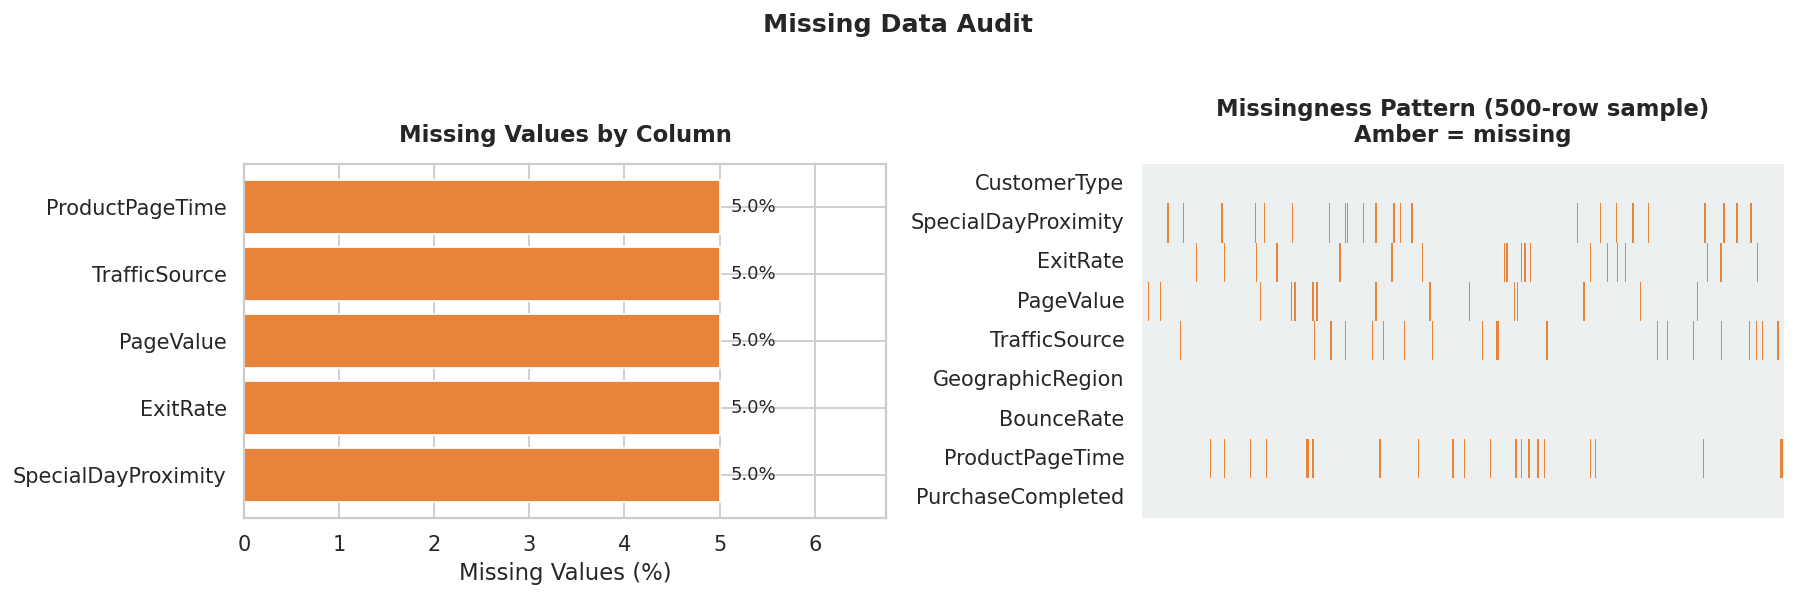


OBSERVATION: All 616 missing values occur in the SAME rows across 5 columns.
This indicates a systematic upstream pipeline failure, not random dropout.


In [9]:
# Missing data visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bars = axes[0].barh(miss_df.index, miss_df["Pct"], color=ACCENT_AMBER, edgecolor="white")
axes[0].bar_label(bars, fmt="%.1f%%", padding=6, fontsize=10)
axes[0].set_xlabel("Missing Values (%)")
axes[0].set_title("Missing Values by Column", pad=12)
axes[0].set_xlim(0, miss_df["Pct"].max() * 1.35)

sample = df_raw.sample(n=500, random_state=42)
sns.heatmap(sample.isnull().astype(int).T, cmap=["#ecf0f1", ACCENT_AMBER],
            cbar=False, yticklabels=True, xticklabels=False, linewidths=0, ax=axes[1])
axes[1].set_title("Missingness Pattern (500-row sample)\nAmber = missing", pad=12)

plt.suptitle("Missing Data Audit", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print()
print("OBSERVATION: All 616 missing values occur in the SAME rows across 5 columns.")
print("This indicates a systematic upstream pipeline failure, not random dropout.")

In [10]:
print(f"Exact duplicate rows: {df_raw.duplicated().sum()}")
print()
print("Raw CustomerType value counts:")
print(df_raw["CustomerType"].value_counts(dropna=False).to_string())

Exact duplicate rows: 393

Raw CustomerType value counts:
CustomerType
Returning_Visitor    10022
New_Visitor           1605
                       166
nan                    153
None                   153
Unknown                144
Other                   83
returning_Visitor        4


In [ ]:
vc = df_raw["PurchaseCompleted"].value_counts()
print(f"No Purchase (0): {vc[0]:>6,}  ({vc[0]/len(df_raw)*100:.1f}%)")
print(f"Purchase    (1): {vc[1]:>6,}  ({vc[1]/len(df_raw)*100:.1f}%)")
print(f"Class imbalance: {vc[0]/vc[1]:.1f}:1")

No Purchase (0): 10,422  (84.5%)
Purchase    (1):  1,908  (15.5%)
Class imbalance: 5.5:1


---
# Section 4. Data Cleaning & Preprocessing

### Cleaning Decision

| Issue | Action |
|-------|--------|
| 616 rows with block-missing values | **Drop rows** |
| 7 dirty `CustomerType` variants | **Normalise** |
| `GeographicRegion` negative sentinels (-9 to -1) | **Map to 'Unknown'** |
| `BounceRate` 348 negative values | **Clip to 0** |
| `ProductPageTime` 4 negative values | **Clip to 0** |
| Exact duplicate rows | **Drop** |

In [11]:
df = df_raw.copy()

# Step 1: Drop missing rows
before = len(df); df.dropna(inplace=True)
print(f"Step 1 — Dropped missing rows: {before-len(df):,}  |  Remaining: {len(df):,}")

# Step 2: Normalise CustomerType
_dirty = {"", "nan", "none", "unknown", "other"}
def norm_ct(val):
    v = str(val).strip().lower()
    if v in _dirty: return "Other/Unknown"
    s = str(val).strip()
    return s.replace("returning_Visitor","Returning_Visitor")

df["CustomerType"] = df["CustomerType"].apply(norm_ct)
print("\nStep 2 — CustomerType after normalisation:")
print(df["CustomerType"].value_counts().to_string())

# Step 3: Map negative regions
df["RegionLabel"] = df["GeographicRegion"].apply(lambda x: str(int(x)) if x>0 else "Unknown")
print(f"\nStep 3 — RegionLabel unique: {sorted(df['RegionLabel'].unique())}")

# Step 4: Clip impossible negatives
neg_br = (df["BounceRate"]<0).sum(); neg_ppt = (df["ProductPageTime"]<0).sum()
df["BounceRate"] = df["BounceRate"].clip(lower=0)
df["ProductPageTime"] = df["ProductPageTime"].clip(lower=0)
print(f"\nStep 4 — Clipped BounceRate negatives: {neg_br},  ProductPageTime negatives: {neg_ppt}")

# Step 5: Drop duplicates
before = len(df); df.drop_duplicates(inplace=True)
print(f"\nStep 5 — Dropped duplicates: {before-len(df)}  |  Remaining: {len(df):,}")

# Step 6: Numeric encode + cast
df["CustomerType_Enc"] = df["CustomerType"].map({"Returning_Visitor":2,"New_Visitor":1,"Other/Unknown":0}).fillna(0).astype(int)
df["TrafficSource"] = df["TrafficSource"].astype(int)

# Store average rate for reuse
avg_rate = df["PurchaseCompleted"].mean() * 100
print(f"\nClean dataset ready  |  Shape: {df.shape}  |  Conversion rate: {avg_rate:.2f}%")

Step 1 — Dropped missing rows: 2,778  |  Remaining: 9,552

Step 2 — CustomerType after normalisation:
CustomerType
Returning_Visitor    7760
New_Visitor          1237
Other/Unknown         555

Step 3 — RegionLabel unique: ['1', '2', '3', '4', '5', '6', '7', '8', '9', 'Unknown']

Step 4 — Clipped BounceRate negatives: 256,  ProductPageTime negatives: 2

Step 5 — Dropped duplicates: 352  |  Remaining: 9,200

Clean dataset ready  |  Shape: (9200, 11)  |  Conversion rate: 16.17%


In [12]:
print("Final dtypes:"); print(df.dtypes)
print(f"\nAny remaining nulls: {df.isnull().any().any()}")
df.head(5)

Final dtypes:
CustomerType            object
SpecialDayProximity    float64
ExitRate               float64
PageValue              float64
TrafficSource            int64
GeographicRegion         int64
BounceRate             float64
ProductPageTime        float64
PurchaseCompleted        int64
RegionLabel             object
CustomerType_Enc         int64
dtype: object

Any remaining nulls: False


,CustomerType,SpecialDayProximity,ExitRate,PageValue,TrafficSource,GeographicRegion,BounceRate,ProductPageTime,PurchaseCompleted,RegionLabel,CustomerType_Enc
0,Returning_Visitor,0.0,0.200000,0.0,1,1,0.200000,0.000000,0,1,2
1,Returning_Visitor,0.0,0.100000,0.0,2,1,0.000000,64.000000,0,1,2
3,Returning_Visitor,0.0,0.140000,0.0,4,2,0.050000,2.666667,0,2,2
5,Returning_Visitor,0.0,0.024561,0.0,3,1,0.015789,154.216667,0,1,2
6,Returning_Visitor,0.4,0.200000,0.0,3,3,0.200000,0.000000,0,3,2


---
# Section 5. Univariate Analysis

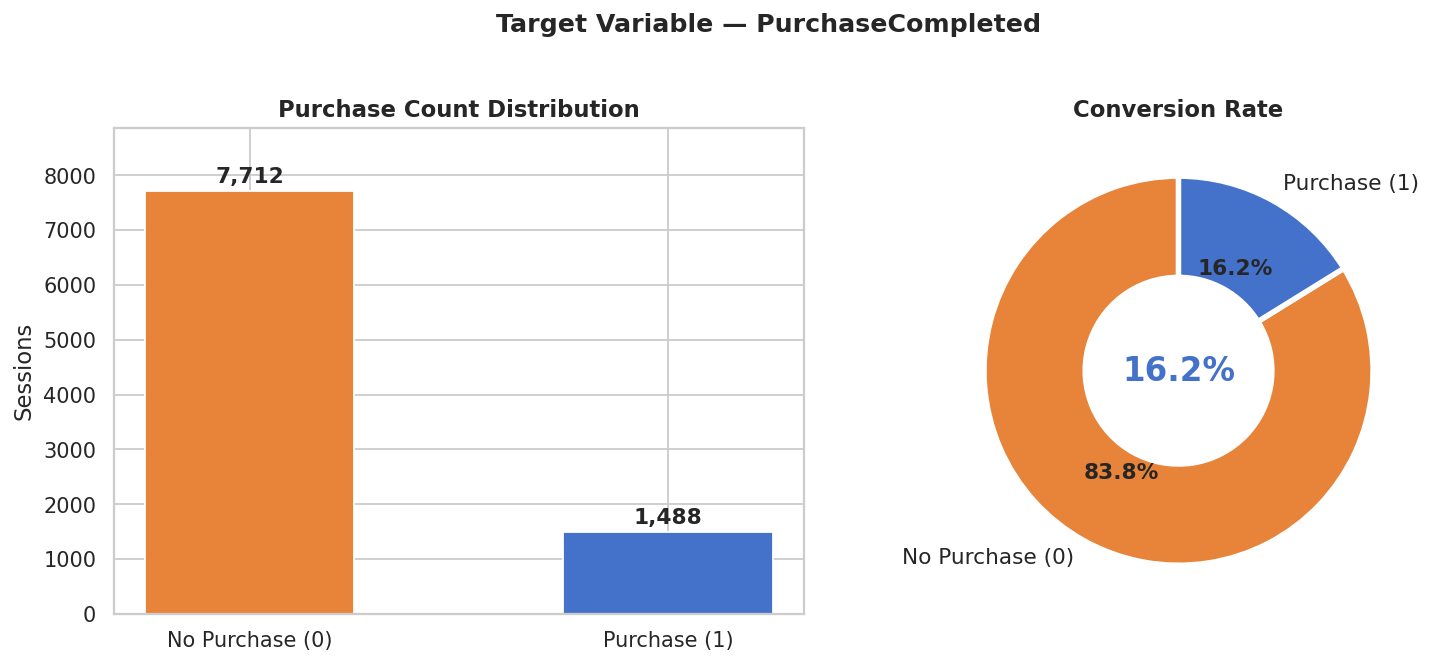


KEY FINDING: Only 15.5% of sessions result in a purchase (84.5/15.5 imbalance).
ML models must explicitly handle this via class_weight, SMOTE, or threshold tuning.


In [14]:
# ── 5a. Target variable ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df["PurchaseCompleted"].value_counts().sort_index().values
labels = ["No Purchase (0)", "Purchase (1)"]
colors = [ACCENT_AMBER, ACCENT_BLUE]

bars = axes[0].bar(labels, counts, color=colors, edgecolor="white", width=0.5)
for bar, n in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
                 f"{n:,}", ha="center", va="bottom", fontweight="bold", fontsize=12)
axes[0].set_title("Purchase Count Distribution"); axes[0].set_ylabel("Sessions")
axes[0].set_ylim(0, max(counts)*1.15)

wedges, texts, autotexts = axes[1].pie(
    counts, labels=labels, autopct="%1.1f%%", colors=colors,
    wedgeprops=dict(width=0.52, edgecolor="white", linewidth=3),
    startangle=90, textprops={"fontsize":12})
for at in autotexts: at.set_fontweight("bold")
axes[1].set_title("Conversion Rate")
axes[1].text(0,0,f"{counts[1]/counts.sum()*100:.1f}%",ha="center",va="center",
             fontsize=18,fontweight="bold",color=ACCENT_BLUE)

plt.suptitle("Target Variable — PurchaseCompleted", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("KEY FINDING: Only 15.5% of sessions result in a purchase (84.5/15.5 imbalance).")
print("ML models must explicitly handle this via class_weight, SMOTE, or threshold tuning.")

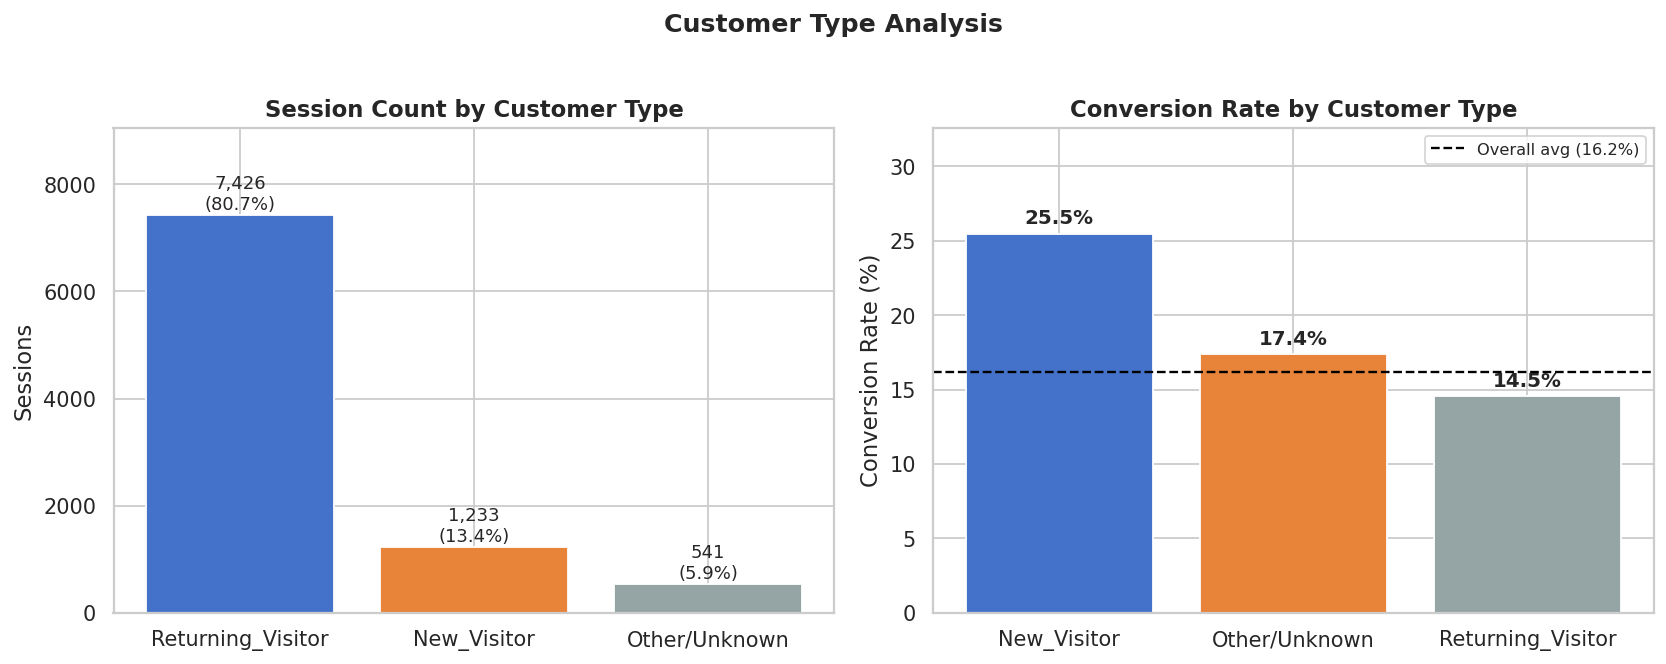


INSIGHT: New_Visitors convert at ~25% vs Returning_Visitors ~14%.
New visitors likely arrive with stronger purchase intent (e.g. from targeted ads).


In [15]:
# ── 5b. CustomerType ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ct_counts  = df["CustomerType"].value_counts()
ct_palette = [ACCENT_BLUE, ACCENT_AMBER, NEUTRAL_GREY]

bars = axes[0].bar(ct_counts.index, ct_counts.values, color=ct_palette[:len(ct_counts)], edgecolor="white")
for bar, n in zip(bars, ct_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"{n:,}\n({n/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Session Count by Customer Type"); axes[0].set_ylabel("Sessions")
axes[0].set_ylim(0, max(ct_counts.values)*1.22)

conv_ct = df.groupby("CustomerType")["PurchaseCompleted"].mean().sort_values(ascending=False)*100
bars2 = axes[1].bar(conv_ct.index, conv_ct.values, color=ct_palette[:len(conv_ct)], edgecolor="white")
for bar, v in zip(bars2, conv_ct.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.4,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label=f"Overall avg ({avg_rate:.1f}%)")
axes[1].set_title("Conversion Rate by Customer Type"); axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_ylim(0, conv_ct.max()*1.28); axes[1].legend(fontsize=9)

plt.suptitle("Customer Type Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("INSIGHT: New_Visitors convert at ~25% vs Returning_Visitors ~14%.")
print("New visitors likely arrive with stronger purchase intent (e.g. from targeted ads).")

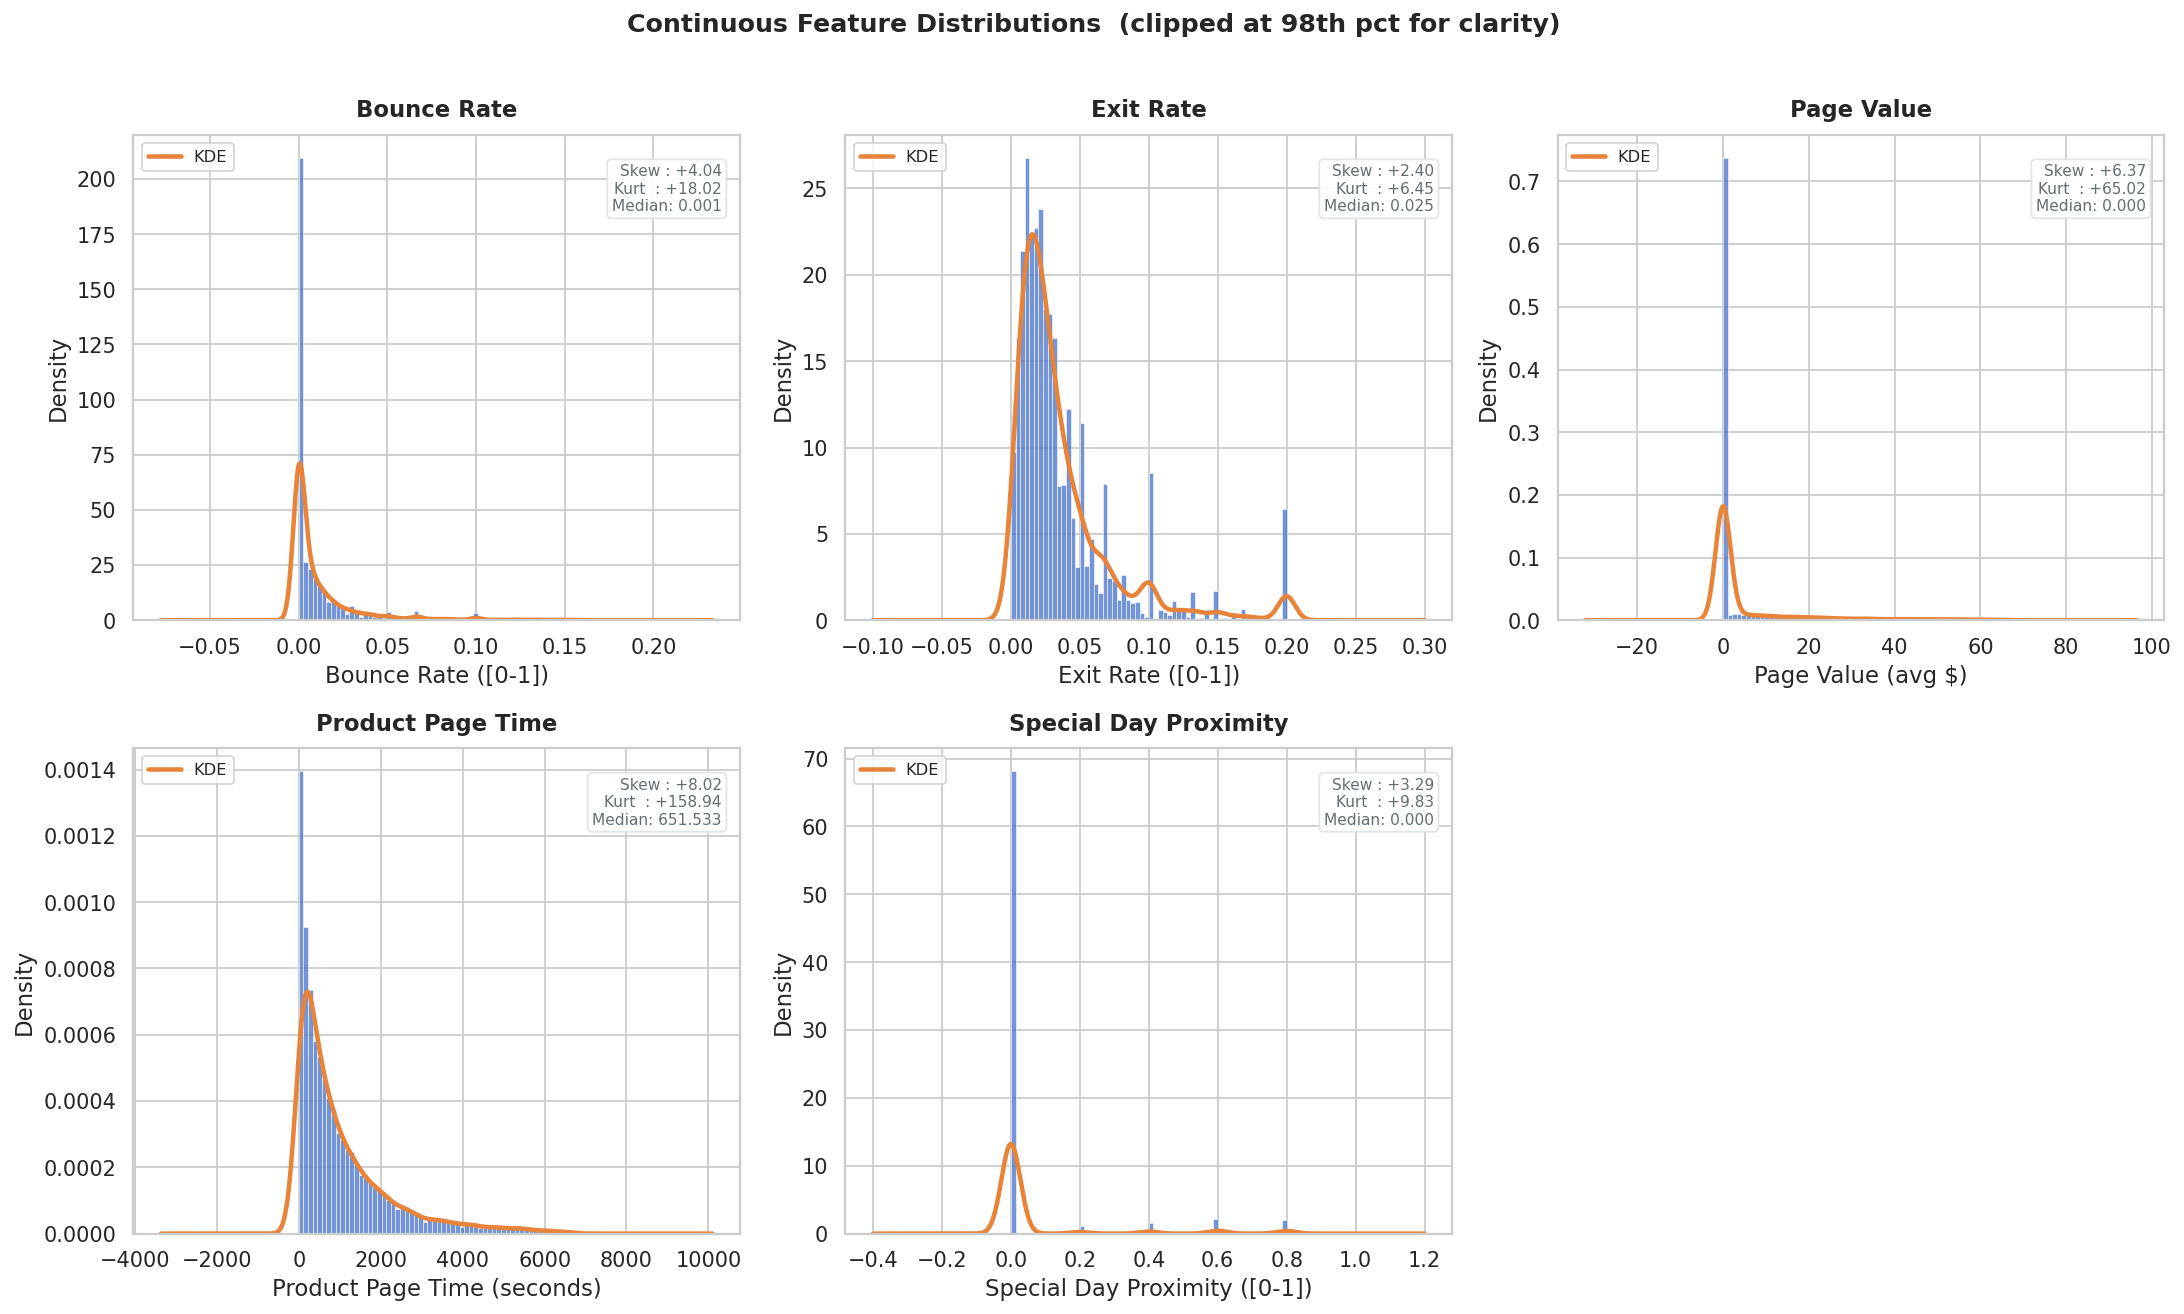


INSIGHTS:
  BounceRate & ExitRate — right-skewed; most sessions have low rates.
  PageValue — zero-inflated; rare high-value pages are the key conversion signal.
  ProductPageTime — heavy right tail; some sessions exceed 60,000 s (idle tabs).
  SpecialDayProximity — dominated by 0; most visits are not near a special day.


In [16]:
# ── 5c. Continuous feature distributions ──────────────────────────────────────
cont_meta = [
    ("BounceRate","Bounce Rate","[0-1]"),
    ("ExitRate","Exit Rate","[0-1]"),
    ("PageValue","Page Value","avg $"),
    ("ProductPageTime","Product Page Time","seconds"),
    ("SpecialDayProximity","Special Day Proximity","[0-1]"),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()
for i, (col, label, unit) in enumerate(cont_meta):
    ax = axes[i]; data = df[col].dropna(); cap = data.quantile(0.98)
    clipped = data[data <= cap]
    ax.hist(clipped, bins=60, color=ACCENT_BLUE, alpha=0.75, density=True, edgecolor="white", linewidth=0.4)
    clipped.plot.kde(ax=ax, color=ACCENT_AMBER, lw=2.5, label="KDE")
    skew = data.skew(); kurt = data.kurt()
    ax.set_title(label, pad=10); ax.set_xlabel(f"{label} ({unit})"); ax.set_ylabel("Density"); ax.legend(fontsize=9)
    ax.text(0.97,0.94,f"Skew : {skew:+.2f}\nKurt  : {kurt:+.2f}\nMedian: {data.median():.3f}",
            transform=ax.transAxes,ha="right",va="top",fontsize=8.5,color="#636e72",
            bbox=dict(boxstyle="round,pad=0.3",fc="white",ec="#dee2e6",alpha=0.9))
axes[-1].set_visible(False)
plt.suptitle("Continuous Feature Distributions  (clipped at 98th pct for clarity)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()
print()
print("INSIGHTS:")
print("  BounceRate & ExitRate — right-skewed; most sessions have low rates.")
print("  PageValue — zero-inflated; rare high-value pages are the key conversion signal.")
print("  ProductPageTime — heavy right tail; some sessions exceed 60,000 s (idle tabs).")
print("  SpecialDayProximity — dominated by 0; most visits are not near a special day.")

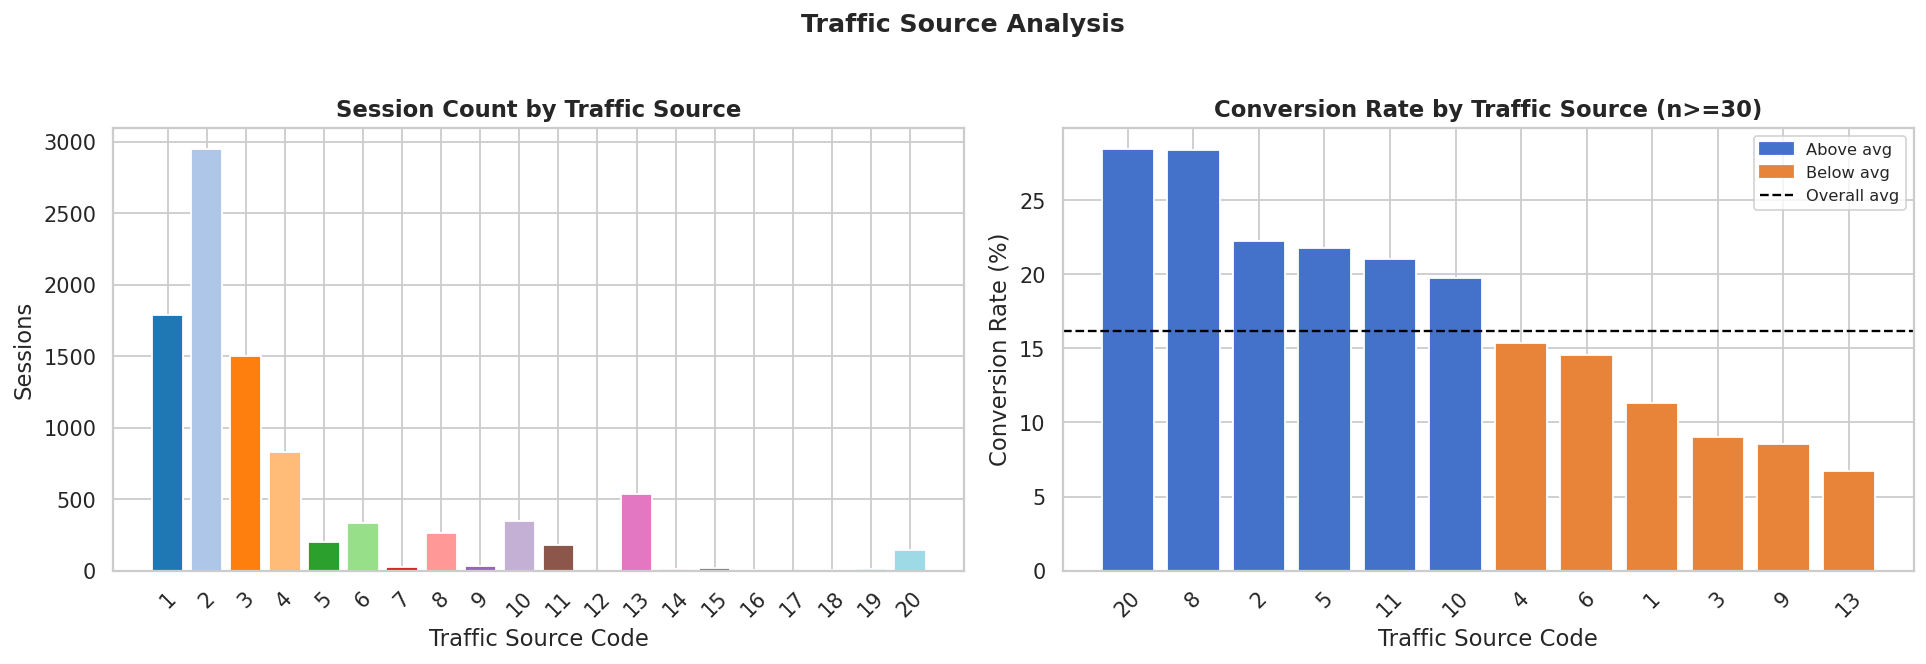


INSIGHT: Sources 1,2,3 drive ~90% of volume. Several minority sources show
markedly higher conversion — prime targets for increased marketing budget.


In [17]:
# ── 5d. Traffic Source ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ts_counts = df["TrafficSource"].value_counts().sort_index()
axes[0].bar(ts_counts.index.astype(str), ts_counts.values,
            color=sns.color_palette("tab20", len(ts_counts)), edgecolor="white")
axes[0].set_title("Session Count by Traffic Source"); axes[0].set_xlabel("Traffic Source Code")
axes[0].set_ylabel("Sessions"); axes[0].tick_params(axis="x", rotation=45)

conv_ts = (df.groupby("TrafficSource")["PurchaseCompleted"]
             .agg(conv_rate="mean", n="count").reset_index())
conv_ts = conv_ts[conv_ts["n"]>=30].sort_values("conv_rate", ascending=False)
conv_ts["conv_rate"] *= 100
bar_colors = [ACCENT_BLUE if r>avg_rate else ACCENT_AMBER for r in conv_ts["conv_rate"]]
axes[1].bar(conv_ts["TrafficSource"].astype(str), conv_ts["conv_rate"],
            color=bar_colors, edgecolor="white")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label=f"Overall avg ({avg_rate:.1f}%)")
axes[1].set_title("Conversion Rate by Traffic Source (n>=30)")
axes[1].set_xlabel("Traffic Source Code"); axes[1].set_ylabel("Conversion Rate (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(handles=[mpatches.Patch(color=ACCENT_BLUE,label="Above avg"),
                         mpatches.Patch(color=ACCENT_AMBER,label="Below avg"),
                         plt.Line2D([0],[0],color="black",ls="--",lw=1.3,label="Overall avg")],fontsize=9)
plt.suptitle("Traffic Source Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("INSIGHT: Sources 1,2,3 drive ~90% of volume. Several minority sources show")
print("markedly higher conversion — prime targets for increased marketing budget.")

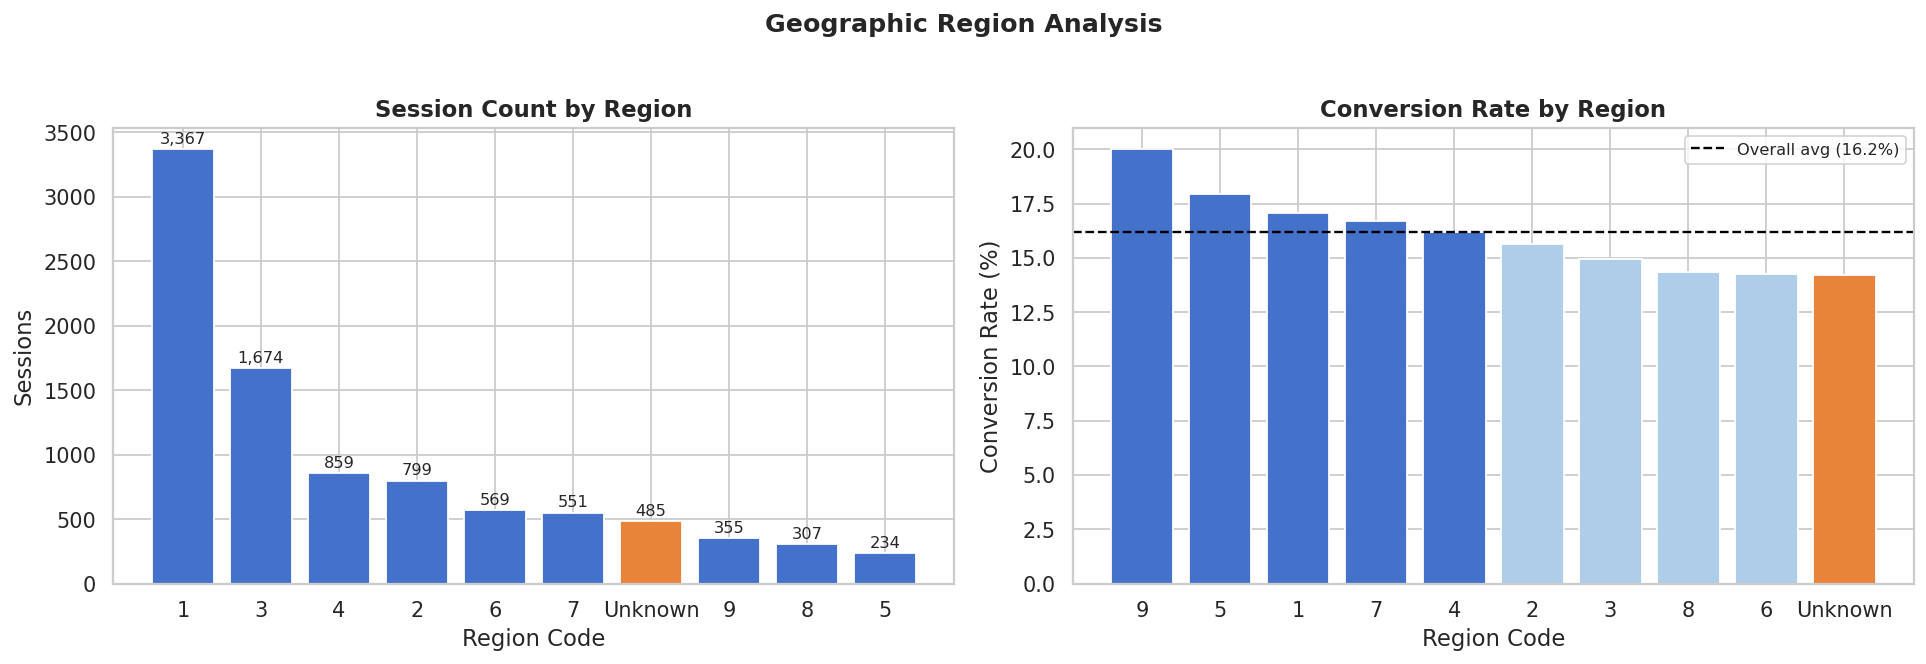


INSIGHT: Region 1 is the largest market. Conversion rates differ meaningfully
across regions — geo-targeted campaigns could lift revenue.


In [18]:
# ── 5e. Geographic Region ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

rg_counts = df["RegionLabel"].value_counts()
rg_palette = [ACCENT_AMBER if r=="Unknown" else ACCENT_BLUE for r in rg_counts.index]
bars = axes[0].bar(rg_counts.index, rg_counts.values, color=rg_palette, edgecolor="white")
for bar, n in zip(bars, rg_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f"{n:,}", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Session Count by Region"); axes[0].set_xlabel("Region Code"); axes[0].set_ylabel("Sessions")

conv_rg = (df.groupby("RegionLabel")["PurchaseCompleted"]
             .agg(conv_rate="mean",n="count").reset_index().sort_values("conv_rate",ascending=False))
conv_rg["conv_rate"] *= 100
rg_colors = [ACCENT_AMBER if r=="Unknown" else
             (ACCENT_BLUE if v>avg_rate else "#aecde8")
             for r,v in zip(conv_rg["RegionLabel"],conv_rg["conv_rate"])]
axes[1].bar(conv_rg["RegionLabel"], conv_rg["conv_rate"], color=rg_colors, edgecolor="white")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label=f"Overall avg ({avg_rate:.1f}%)")
axes[1].set_title("Conversion Rate by Region"); axes[1].set_xlabel("Region Code")
axes[1].set_ylabel("Conversion Rate (%)"); axes[1].legend(fontsize=9)
plt.suptitle("Geographic Region Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("INSIGHT: Region 1 is the largest market. Conversion rates differ meaningfully")
print("across regions — geo-targeted campaigns could lift revenue.")

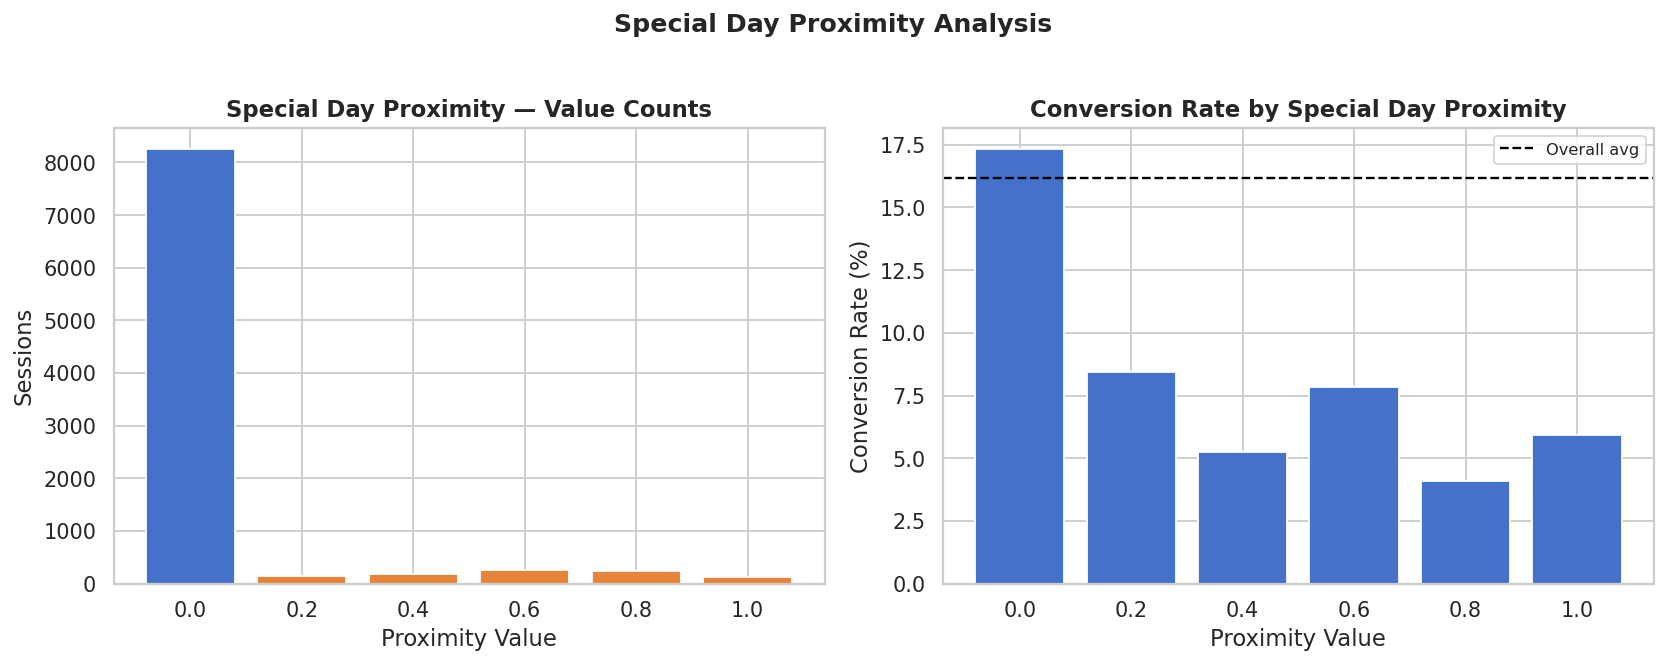


INSIGHT: >85% of sessions have proximity=0. Counter-intuitively, conversion
is LOWER near special days — likely window-shopping / deal-browsing behaviour.


In [19]:
# ── 5f. SpecialDayProximity ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sdp_counts = df["SpecialDayProximity"].value_counts().sort_index()
axes[0].bar(sdp_counts.index.astype(str), sdp_counts.values,
            color=[ACCENT_AMBER if v>0 else ACCENT_BLUE for v in sdp_counts.index], edgecolor="white")
axes[0].set_title("Special Day Proximity — Value Counts")
axes[0].set_xlabel("Proximity Value"); axes[0].set_ylabel("Sessions")

conv_sdp = df.groupby("SpecialDayProximity")["PurchaseCompleted"].mean().sort_index()*100
axes[1].bar(conv_sdp.index.astype(str), conv_sdp.values, color=ACCENT_BLUE, edgecolor="white")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label="Overall avg")
axes[1].set_title("Conversion Rate by Special Day Proximity")
axes[1].set_xlabel("Proximity Value"); axes[1].set_ylabel("Conversion Rate (%)"); axes[1].legend(fontsize=9)
plt.suptitle("Special Day Proximity Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("INSIGHT: >85% of sessions have proximity=0. Counter-intuitively, conversion")
print("is LOWER near special days — likely window-shopping / deal-browsing behaviour.")

---
# Section 6. Bivariate & Multivariate Analysis

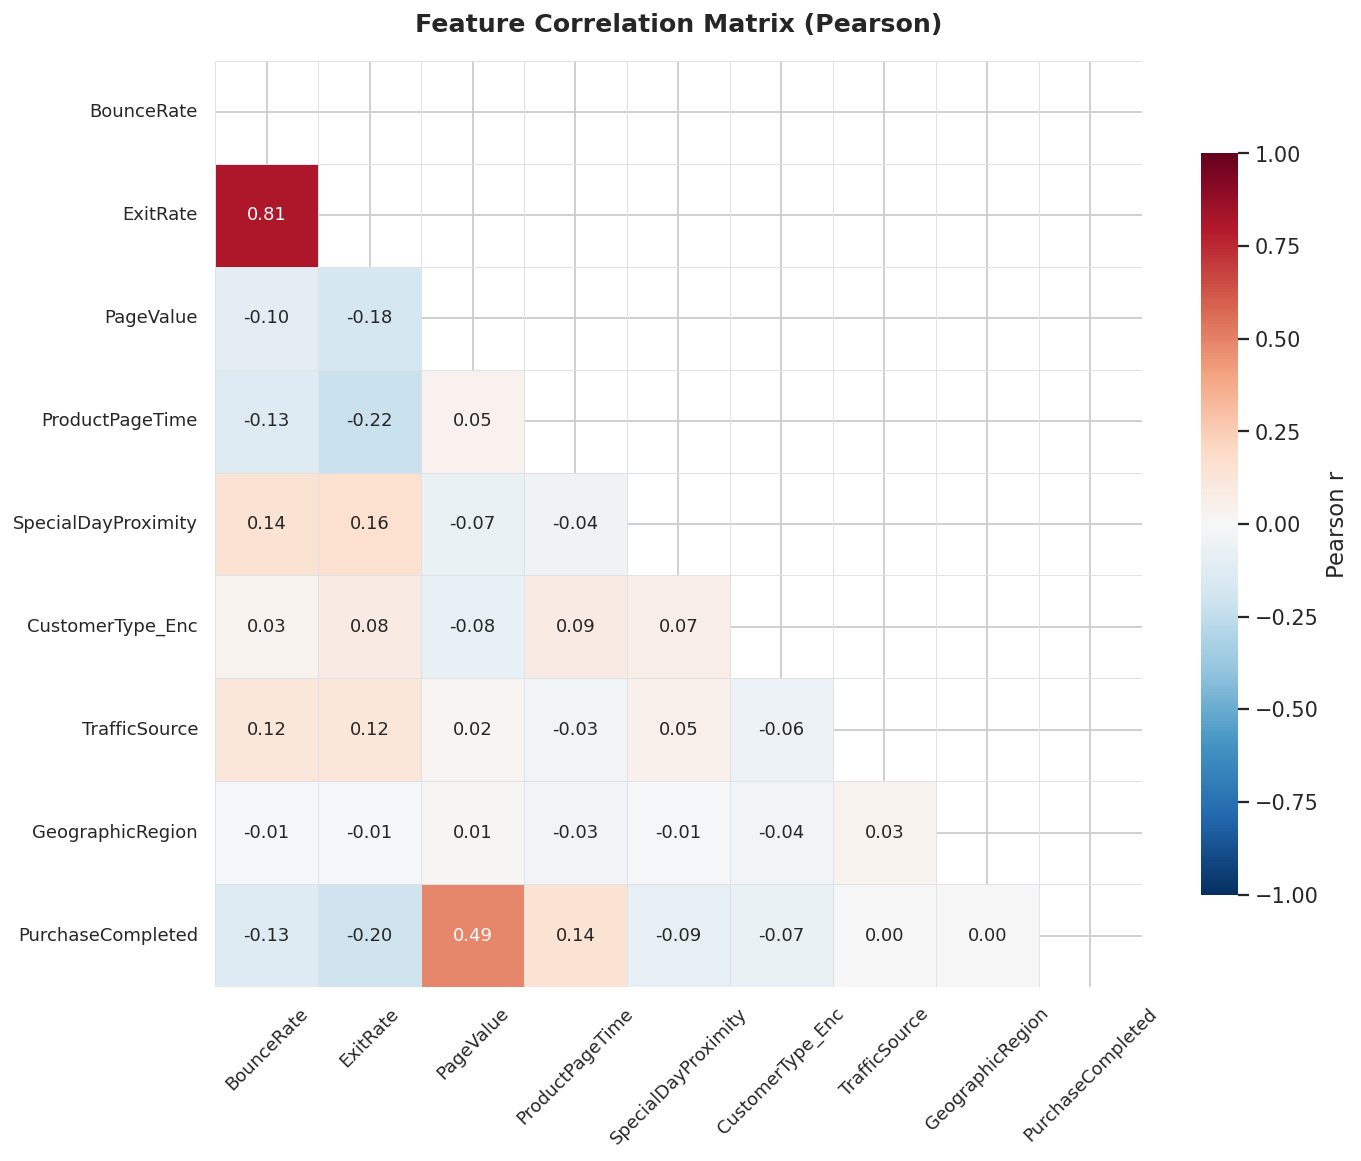


KEY CORRELATIONS with PurchaseCompleted:
  PageValue                  +0.488  ██████████████
  ExitRate                   -0.204  ██████
  ProductPageTime            +0.142  ████
  BounceRate                 -0.130  ███
  SpecialDayProximity        -0.087  ██
  CustomerType_Enc           -0.068  ██
  GeographicRegion           +0.004  
  TrafficSource              +0.002  


In [20]:
# ── 6a. Full correlation heatmap ──────────────────────────────────────────────
numeric_cols = ["BounceRate","ExitRate","PageValue","ProductPageTime",
                "SpecialDayProximity","CustomerType_Enc","TrafficSource",
                "GeographicRegion","PurchaseCompleted"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="#dee2e6",
            ax=ax, annot_kws={"size":10}, cbar_kws={"shrink":0.8,"label":"Pearson r"}, square=True)
ax.set_title("Feature Correlation Matrix (Pearson)", pad=16, fontsize=14)
ax.tick_params(axis="x", rotation=45, labelsize=10); ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout(); plt.show()

print(); print("KEY CORRELATIONS with PurchaseCompleted:")
target_corr = corr["PurchaseCompleted"].drop("PurchaseCompleted").sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    bar = chr(9608)*int(abs(val)*30); d = "+" if val>=0 else "-"
    print(f"  {feat:25s}  {d}{abs(val):.3f}  {bar}")

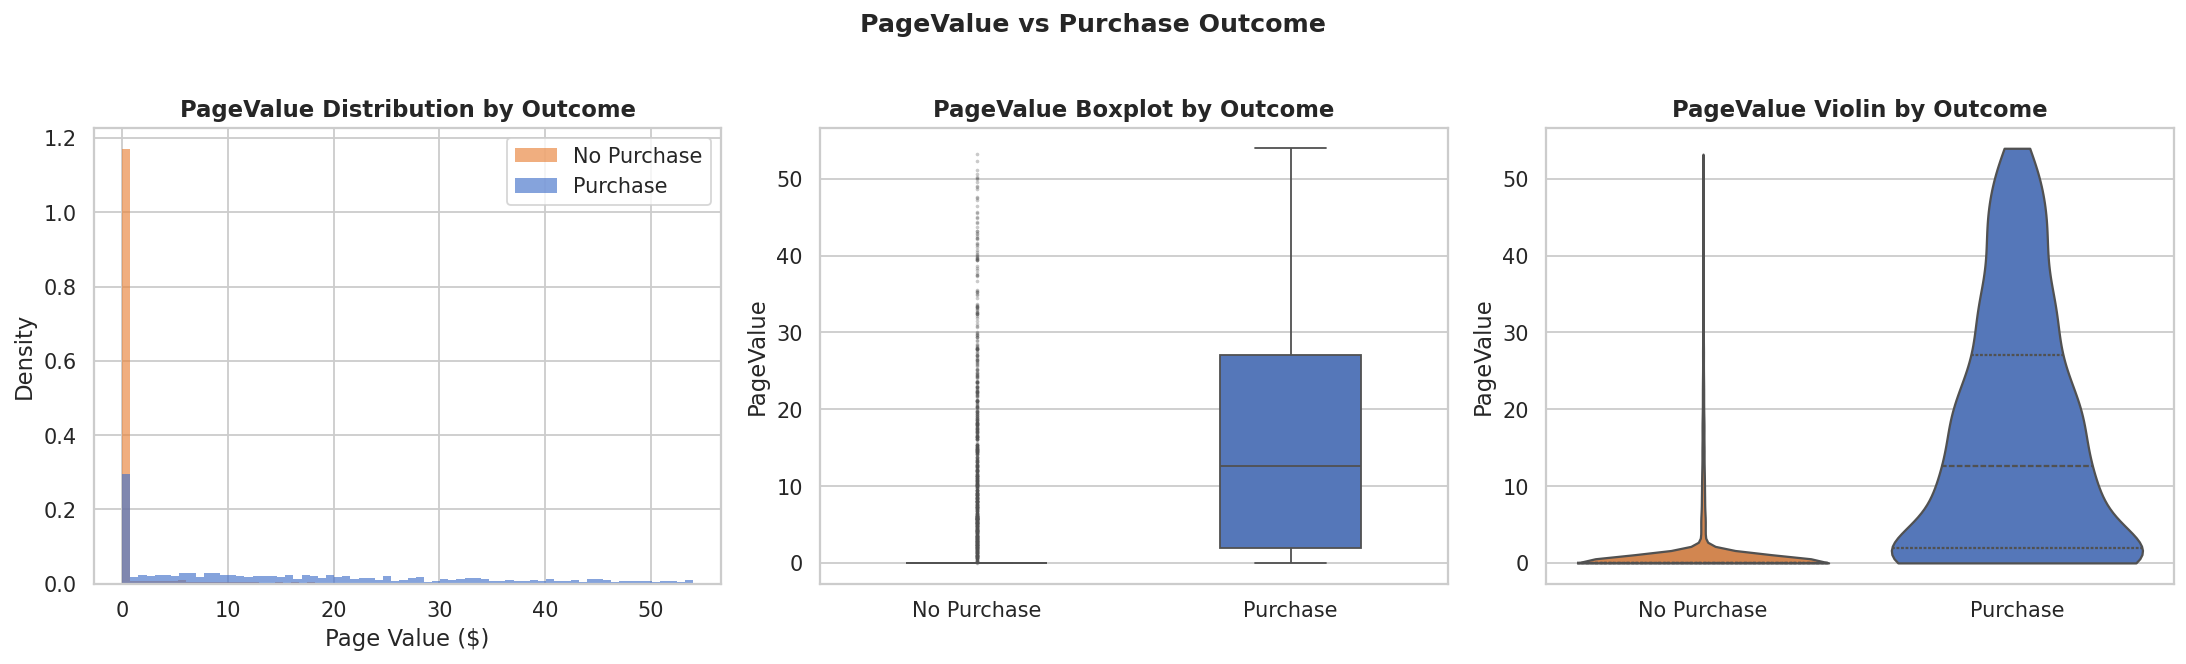


Mean PageValue — No Purchase: $2.08
Mean PageValue — Purchase   : $27.60  (13.3x higher)

INSIGHT: Purchasing sessions have PageValue ~10x higher than non-purchasing.
This is the single strongest predictor in the dataset.


In [21]:
# ── 6b. PageValue — the star predictor ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cap_pv = df["PageValue"].quantile(0.97)
df_pv  = df[df["PageValue"]<=cap_pv].copy()
df_pv["Outcome"] = df_pv["PurchaseCompleted"].map({0:"No Purchase",1:"Purchase"})

for val, color, lbl in [(0,ACCENT_AMBER,"No Purchase"),(1,ACCENT_BLUE,"Purchase")]:
    subset = df_pv[df_pv["PurchaseCompleted"]==val]["PageValue"]
    axes[0].hist(subset, bins=70, alpha=0.65, color=color, label=lbl, density=True, edgecolor="none")
axes[0].set_xlabel("Page Value ($)"); axes[0].set_ylabel("Density")
axes[0].set_title("PageValue Distribution by Outcome"); axes[0].legend()

sns.boxplot(data=df_pv, x="Outcome", y="PageValue",
            palette={"No Purchase":ACCENT_AMBER,"Purchase":ACCENT_BLUE},
            width=0.45, flierprops=dict(marker=".",ms=2,alpha=0.3), ax=axes[1])
axes[1].set_title("PageValue Boxplot by Outcome"); axes[1].set_xlabel("")

sns.violinplot(data=df_pv, x="Outcome", y="PageValue",
               palette={"No Purchase":ACCENT_AMBER,"Purchase":ACCENT_BLUE},
               inner="quartile", cut=0, ax=axes[2])
axes[2].set_title("PageValue Violin by Outcome"); axes[2].set_xlabel("")

plt.suptitle("PageValue vs Purchase Outcome", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

mn = df[df["PurchaseCompleted"]==0]["PageValue"].mean()
my = df[df["PurchaseCompleted"]==1]["PageValue"].mean()
print(f"\nMean PageValue — No Purchase: ${mn:.2f}")
print(f"Mean PageValue — Purchase   : ${my:.2f}  ({my/mn:.1f}x higher)")
print()
print("INSIGHT: Purchasing sessions have PageValue ~10x higher than non-purchasing.")
print("This is the single strongest predictor in the dataset.")

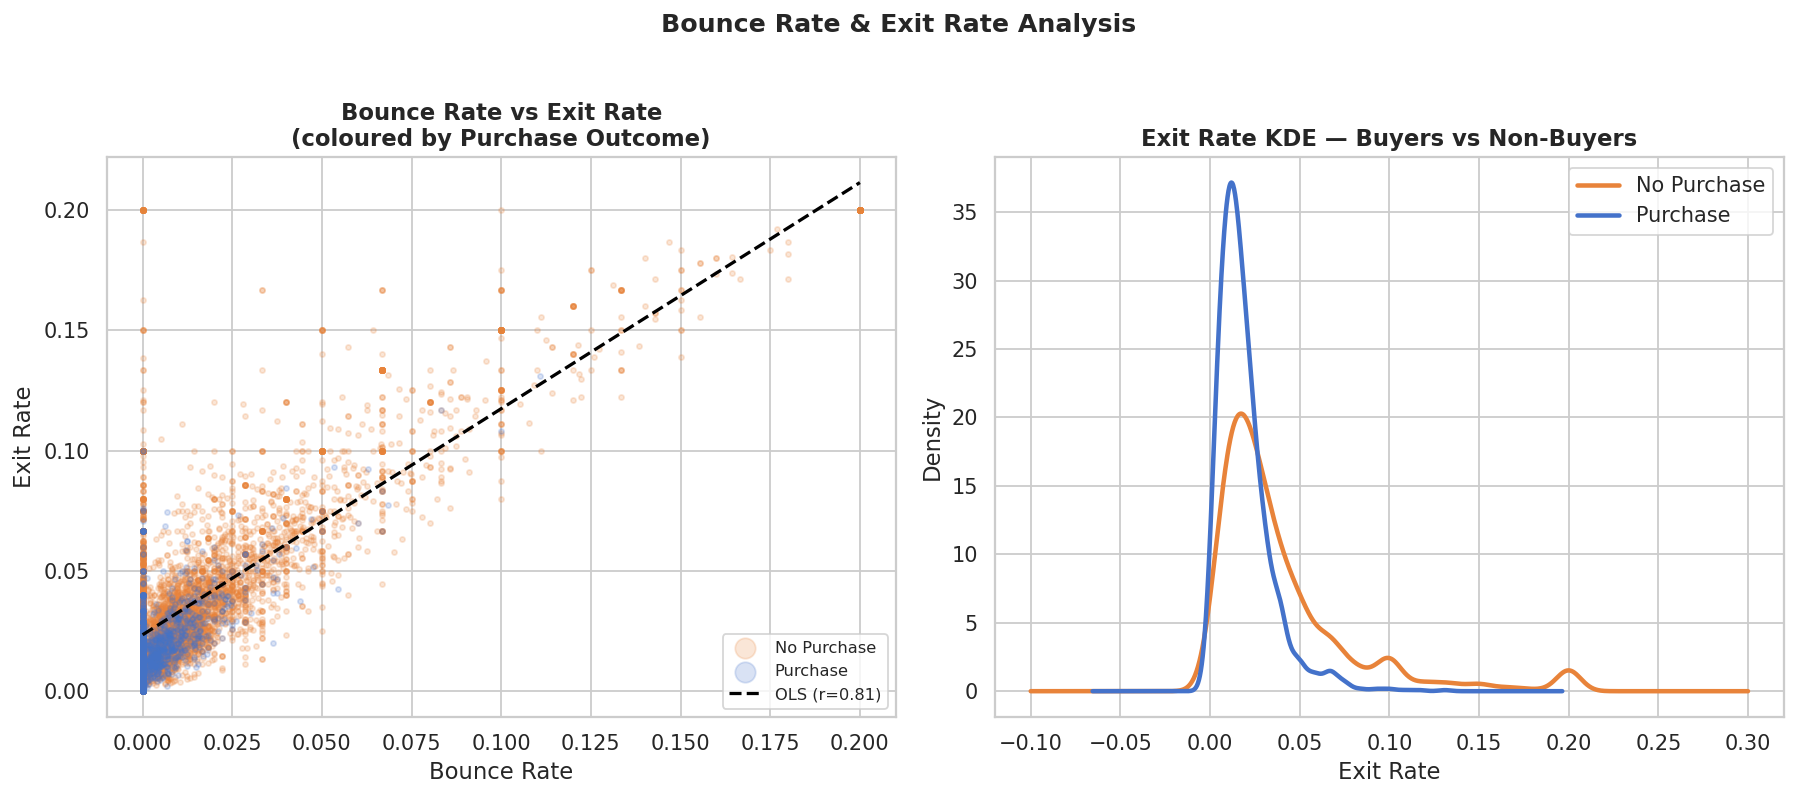


BounceRate vs ExitRate correlation: 0.812
INSIGHT: Highly correlated (r~0.81) — use only ONE in ML models (prefer ExitRate).


In [22]:
# ── 6c. BounceRate vs ExitRate ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for val, color, lbl in [(0,ACCENT_AMBER,"No Purchase"),(1,ACCENT_BLUE,"Purchase")]:
    g = df[df["PurchaseCompleted"]==val]
    axes[0].scatter(g["BounceRate"], g["ExitRate"], alpha=0.2, s=8, color=color, label=lbl)
m, b = np.polyfit(df["BounceRate"], df["ExitRate"], 1)
x_rng = np.linspace(0, df["BounceRate"].max(), 100)
r_be  = df[["BounceRate","ExitRate"]].corr().iloc[0,1]
axes[0].plot(x_rng, m*x_rng+b, color="black", lw=1.8, ls="--", label=f"OLS (r={r_be:.2f})")
axes[0].set_xlabel("Bounce Rate"); axes[0].set_ylabel("Exit Rate")
axes[0].set_title("Bounce Rate vs Exit Rate\n(coloured by Purchase Outcome)"); axes[0].legend(markerscale=4, fontsize=9)

for val, color, lbl in [(0,ACCENT_AMBER,"No Purchase"),(1,ACCENT_BLUE,"Purchase")]:
    df[df["PurchaseCompleted"]==val]["ExitRate"].plot.kde(ax=axes[1], color=color, lw=2.5, label=lbl)
axes[1].set_xlabel("Exit Rate"); axes[1].set_ylabel("Density")
axes[1].set_title("Exit Rate KDE — Buyers vs Non-Buyers"); axes[1].legend()

plt.suptitle("Bounce Rate & Exit Rate Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print(f"\nBounceRate vs ExitRate correlation: {r_be:.3f}")
print("INSIGHT: Highly correlated (r~0.81) — use only ONE in ML models (prefer ExitRate).")

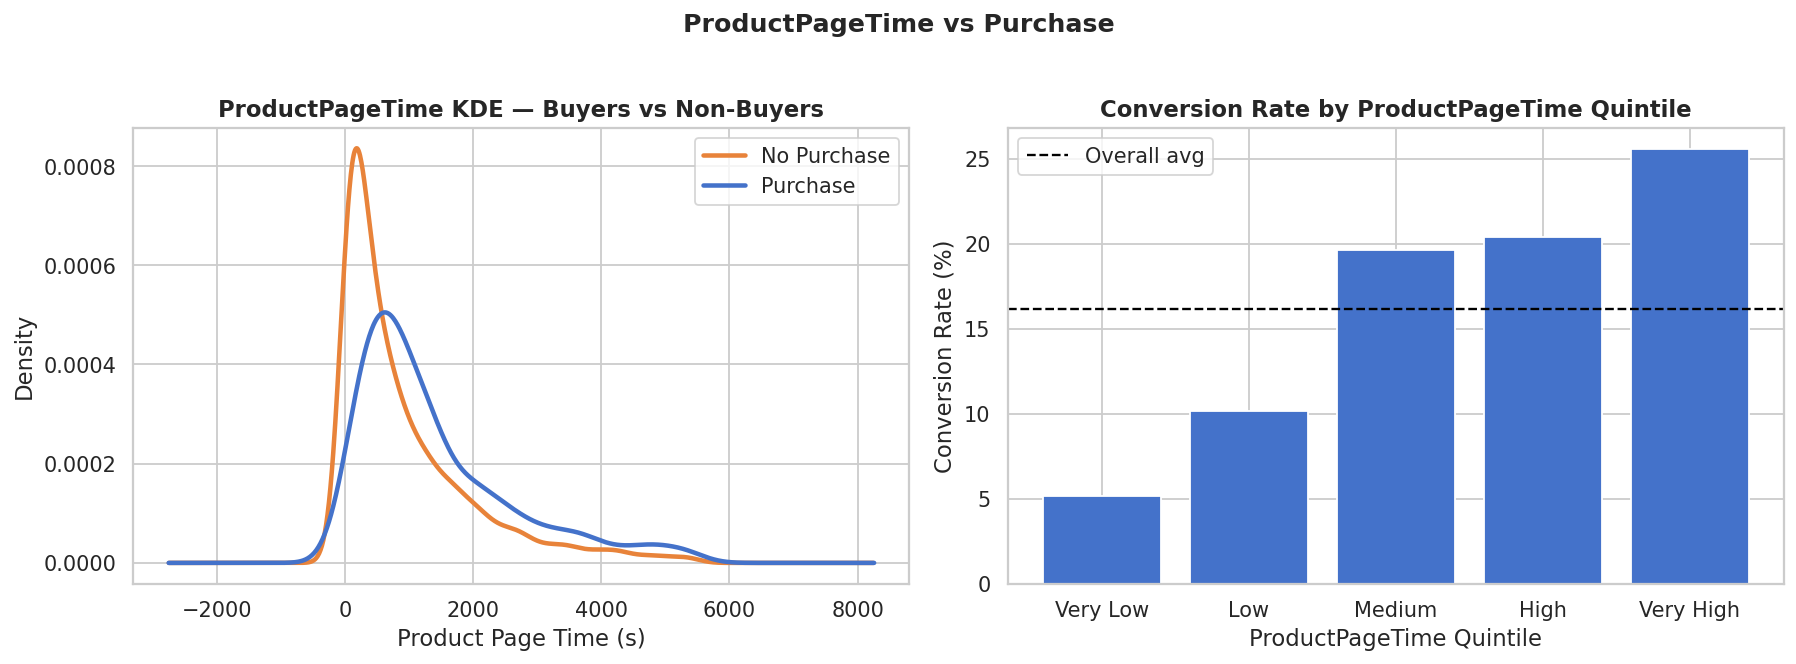


INSIGHT: Conversion rises monotonically with time on product pages.
Very High quintile converts nearly 2x the overall average.


In [23]:
# ── 6d. ProductPageTime vs Purchase ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cap_ppt = df["ProductPageTime"].quantile(0.97)
df_ppt  = df[df["ProductPageTime"]<=cap_ppt]

for val, color, lbl in [(0,ACCENT_AMBER,"No Purchase"),(1,ACCENT_BLUE,"Purchase")]:
    df_ppt[df_ppt["PurchaseCompleted"]==val]["ProductPageTime"].plot.kde(ax=axes[0], color=color, lw=2.5, label=lbl)
axes[0].set_xlabel("Product Page Time (s)"); axes[0].set_ylabel("Density")
axes[0].set_title("ProductPageTime KDE — Buyers vs Non-Buyers"); axes[0].legend()

df_ppt2 = df.copy()
df_ppt2["time_bin"] = pd.qcut(df_ppt2["ProductPageTime"].clip(upper=cap_ppt), q=5,
                               labels=["Very Low","Low","Medium","High","Very High"])
time_conv = df_ppt2.groupby("time_bin",observed=True)["PurchaseCompleted"].mean()*100
axes[1].bar(time_conv.index, time_conv.values, color=ACCENT_BLUE, edgecolor="white")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label="Overall avg")
axes[1].set_xlabel("ProductPageTime Quintile"); axes[1].set_ylabel("Conversion Rate (%)")
axes[1].set_title("Conversion Rate by ProductPageTime Quintile"); axes[1].legend()

plt.suptitle("ProductPageTime vs Purchase", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("INSIGHT: Conversion rises monotonically with time on product pages.")
print("Very High quintile converts nearly 2x the overall average.")

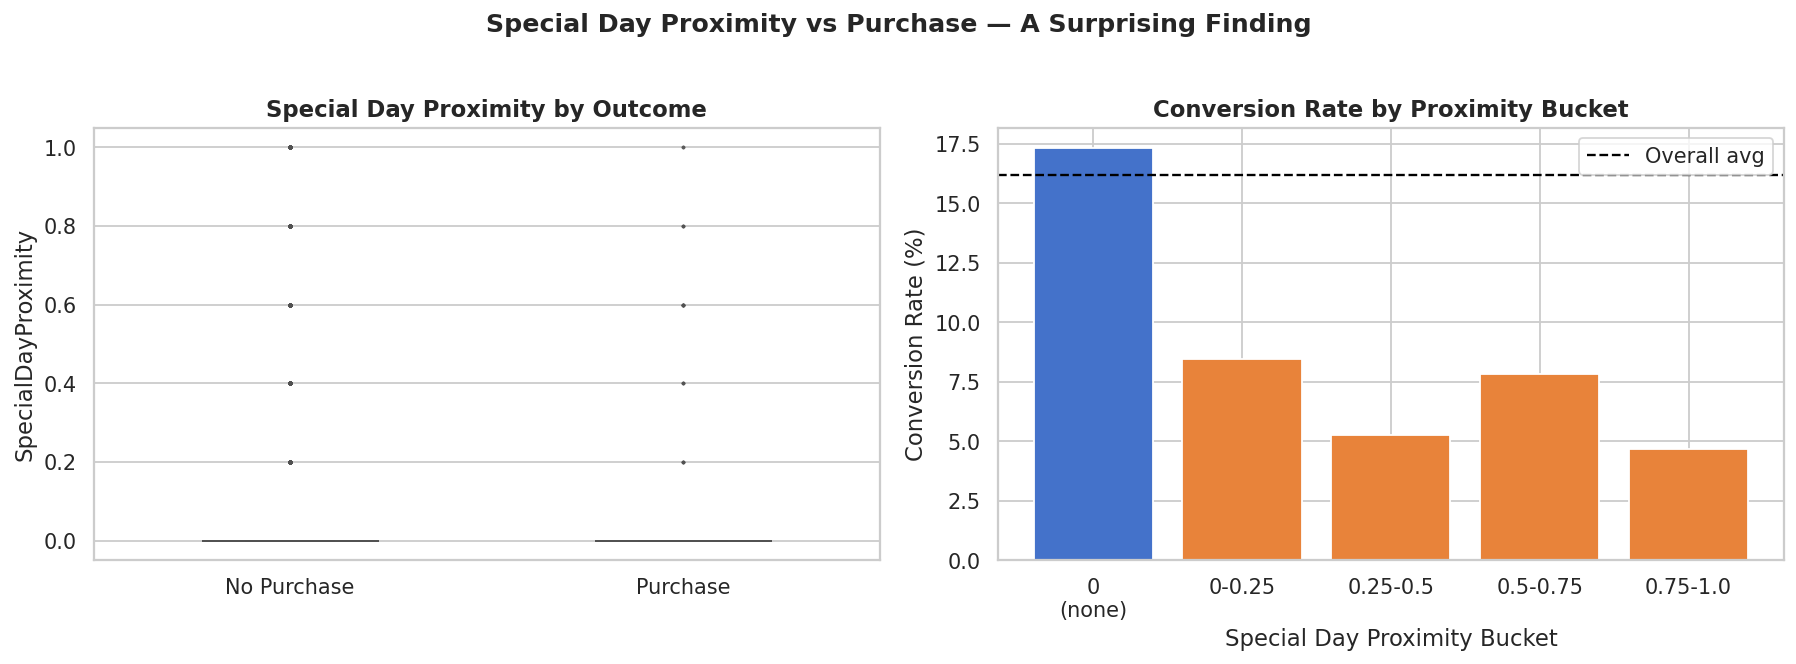


SURPRISING FINDING: Sessions near special shopping days show LOWER conversion.
Traffic surges on special days likely dilute conversion with casual browsers.
Implication: Urgency/scarcity messaging needed to convert special-day traffic.


In [24]:
# ── 6e. SpecialDayProximity counter-intuitive finding ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_sdp2 = df.copy()
df_sdp2["Outcome"] = df_sdp2["PurchaseCompleted"].map({0:"No Purchase",1:"Purchase"})
sns.boxplot(data=df_sdp2, x="Outcome", y="SpecialDayProximity",
            palette={"No Purchase":ACCENT_AMBER,"Purchase":ACCENT_BLUE},
            width=0.45, ax=axes[0], flierprops=dict(marker=".",ms=2,alpha=0.3))
axes[0].set_title("Special Day Proximity by Outcome"); axes[0].set_xlabel("")

df_sdp2["prox_bin"] = pd.cut(df_sdp2["SpecialDayProximity"],
    bins=[-0.01,0,0.25,0.5,0.75,1.01], labels=["0\n(none)","0-0.25","0.25-0.5","0.5-0.75","0.75-1.0"])
prox_conv = df_sdp2.groupby("prox_bin",observed=True)["PurchaseCompleted"].mean()*100
axes[1].bar(prox_conv.index, prox_conv.values,
            color=[ACCENT_BLUE if v>=avg_rate else ACCENT_AMBER for v in prox_conv.values], edgecolor="white")
axes[1].axhline(avg_rate, color="black", ls="--", lw=1.3, label="Overall avg")
axes[1].set_title("Conversion Rate by Proximity Bucket")
axes[1].set_xlabel("Special Day Proximity Bucket"); axes[1].set_ylabel("Conversion Rate (%)"); axes[1].legend()

plt.suptitle("Special Day Proximity vs Purchase — A Surprising Finding",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print()
print("SURPRISING FINDING: Sessions near special shopping days show LOWER conversion.")
print("Traffic surges on special days likely dilute conversion with casual browsers.")
print("Implication: Urgency/scarcity messaging needed to convert special-day traffic.")

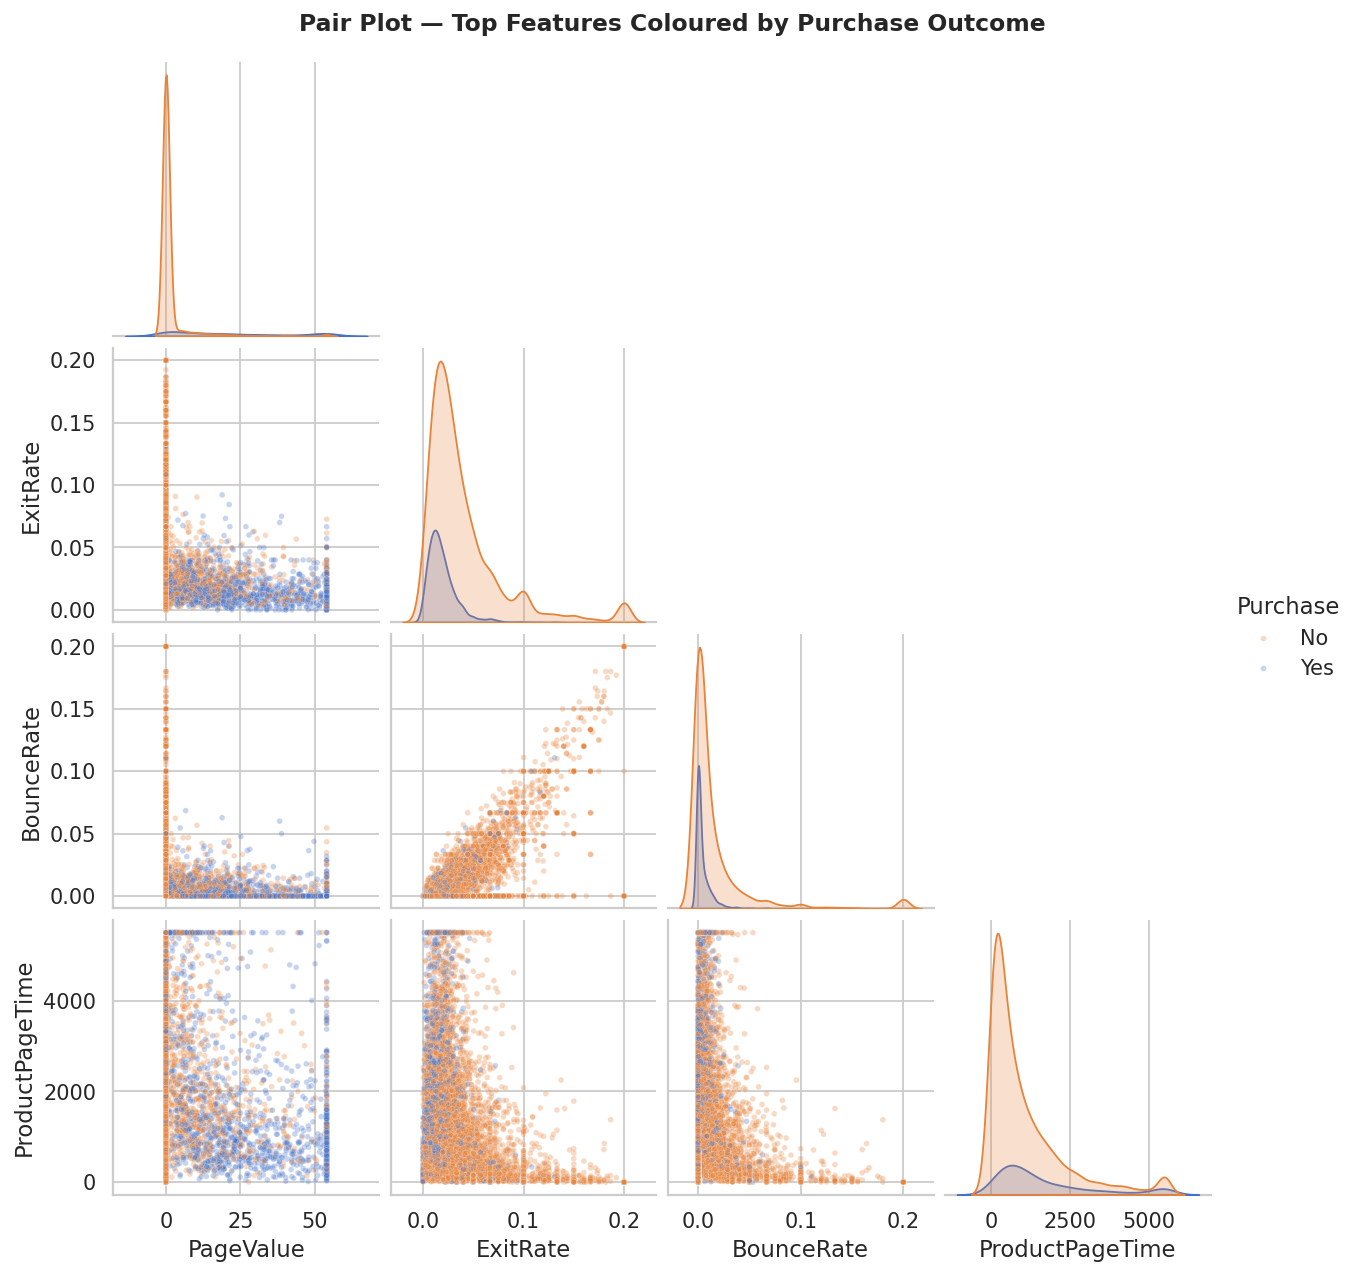


INSIGHT: PageValue is the clearest separator across every pairwise combination.


In [25]:
# ── 6f. Pair plot ─────────────────────────────────────────────────────────────
pair_cols = ["PageValue","ExitRate","BounceRate","ProductPageTime","PurchaseCompleted"]
df_pair   = df[pair_cols].copy()
for c in ["PageValue","ProductPageTime"]:
    df_pair[c] = df_pair[c].clip(upper=df_pair[c].quantile(0.97))
df_pair["Purchase"] = df_pair["PurchaseCompleted"].map({0:"No",1:"Yes"})

g = sns.pairplot(df_pair.drop(columns="PurchaseCompleted"),
                 hue="Purchase", palette={"No":ACCENT_AMBER,"Yes":ACCENT_BLUE},
                 diag_kind="kde", plot_kws={"alpha":0.3,"s":10}, corner=True, height=2.4)
g.figure.suptitle("Pair Plot — Top Features Coloured by Purchase Outcome",
                   fontsize=13, fontweight="bold", y=1.02)
plt.show()
print()
print("INSIGHT: PageValue is the clearest separator across every pairwise combination.")

In [26]:
# ── 6g. Grouped aggregation table ─────────────────────────────────────────────
agg_table = df.groupby("CustomerType").agg(
    Sessions          = ("PurchaseCompleted","count"),
    Conversion_Pct    = ("PurchaseCompleted", lambda x: round(x.mean()*100,2)),
    Avg_PageValue     = ("PageValue",         lambda x: round(x.mean(),2)),
    Avg_BounceRate    = ("BounceRate",        lambda x: round(x.mean(),4)),
    Avg_ExitRate      = ("ExitRate",          lambda x: round(x.mean(),4)),
    Avg_ProdPageTime  = ("ProductPageTime",   lambda x: round(x.mean(),1)),
).sort_values("Conversion_Pct", ascending=False)
print("Aggregated metrics by CustomerType:")
print(agg_table.to_string())

Aggregated metrics by CustomerType:
                   Sessions  Conversion_Pct  Avg_PageValue  Avg_BounceRate  Avg_ExitRate  Avg_ProdPageTime
CustomerType                                                                                              
New_Visitor            1233           25.47          10.87          0.0046        0.0200             642.2
Other/Unknown           541           17.38           8.07          0.0203        0.0414            1134.8
Returning_Visitor      7426           14.54           5.29          0.0155        0.0393            1348.2


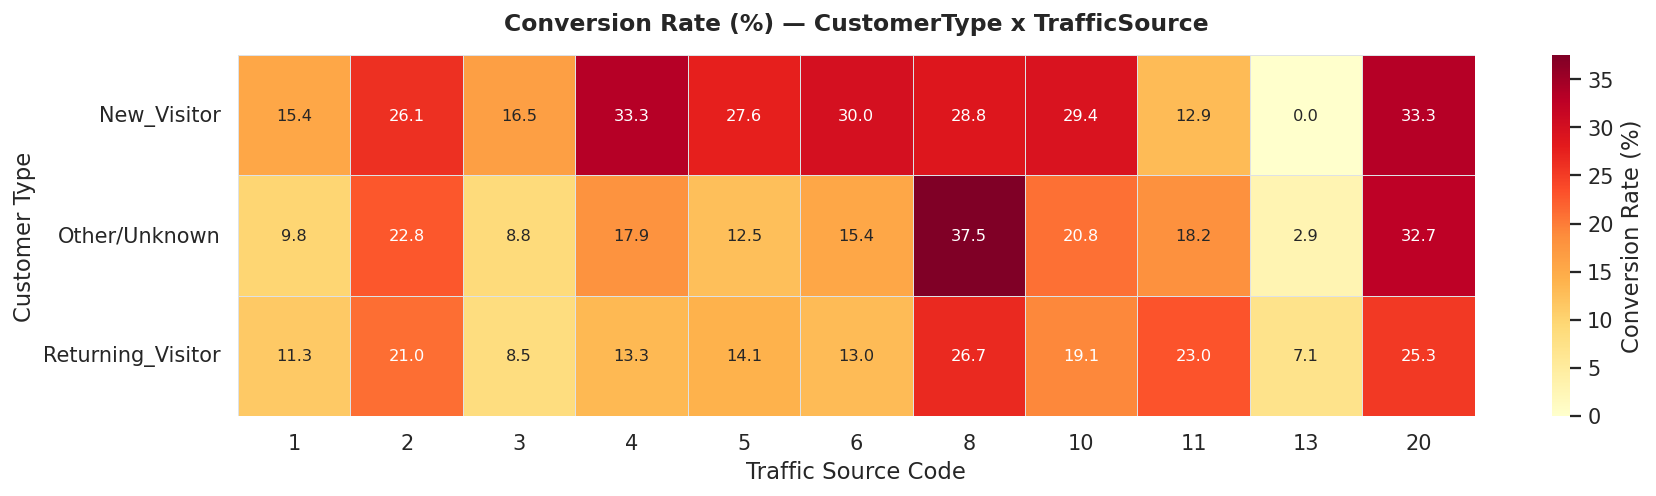


INSIGHT: New_Visitors consistently outperform Returning_Visitors, but the magnitude
varies by channel — revealing segment-channel interactions for personalised strategies.


In [27]:
# ── 6h. Heatmap: Conversion by TrafficSource x CustomerType ─────────────────
pivot = df.pivot_table(values="PurchaseCompleted", index="CustomerType",
                       columns="TrafficSource", aggfunc="mean") * 100
keep_src = df.groupby("TrafficSource").size()
keep_src = keep_src[keep_src>=50].index
pivot = pivot[[c for c in pivot.columns if c in keep_src]]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, linecolor="#dee2e6", ax=ax,
            cbar_kws={"label":"Conversion Rate (%)"}, annot_kws={"size":9})
ax.set_title("Conversion Rate (%) — CustomerType x TrafficSource", pad=14, fontsize=13)
ax.set_xlabel("Traffic Source Code"); ax.set_ylabel("Customer Type")
plt.tight_layout(); plt.show()
print()
print("INSIGHT: New_Visitors consistently outperform Returning_Visitors, but the magnitude")
print("varies by channel — revealing segment-channel interactions for personalised strategies.")

---
# Section 7. Feature Insights & ML Readiness

In [28]:
# ── Point-biserial correlation ────────────────────────────────────────────────
cont_features = ["PageValue","ExitRate","BounceRate","ProductPageTime","SpecialDayProximity","CustomerType_Enc"]
results = []
for feat in cont_features:
    r, p = pointbiserialr(df[feat], df["PurchaseCompleted"])
    results.append({"Feature":feat, "Pearson r":round(r,4), "|r|":round(abs(r),4),
                    "p-value":p, "Sig":"p<0.001" if p<0.001 else ("p<0.05" if p<0.05 else "n.s.")})
feat_df = pd.DataFrame(results).set_index("Feature").sort_values("|r|", ascending=False)
print("Point-Biserial Correlation with PurchaseCompleted:")
print(feat_df.drop(columns="|r|").to_string())

Point-Biserial Correlation with PurchaseCompleted:
                     Pearson r       p-value      Sig
Feature                                              
PageValue               0.4877  0.000000e+00  p<0.001
ExitRate               -0.2044  2.128174e-87  p<0.001
ProductPageTime         0.1422  9.359017e-43  p<0.001
BounceRate             -0.1298  7.601904e-36  p<0.001
SpecialDayProximity    -0.0872  5.323538e-17  p<0.001
CustomerType_Enc       -0.0681  6.255817e-11  p<0.001


In [29]:
# ── Cramer's V ────────────────────────────────────────────────────────────────
cat_features = ["CustomerType","TrafficSource","RegionLabel"]
cramers_results = []
for feat in cat_features:
    ct = pd.crosstab(df[feat], df["PurchaseCompleted"])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum(); k = min(ct.shape)-1
    v = np.sqrt(chi2/(n*k))
    cramers_results.append({"Feature":feat,"Cramer V":round(v,4),"p-value":round(p,6)})
cramers_df = pd.DataFrame(cramers_results).set_index("Feature").sort_values("Cramer V", ascending=False)
print("Cramer's V (categorical association with PurchaseCompleted):")
print(cramers_df.to_string())

Cramer's V (categorical association with PurchaseCompleted):
               Cramer V   p-value
Feature                          
TrafficSource    0.1723  0.000000
CustomerType     0.1009  0.000000
RegionLabel      0.0365  0.198023


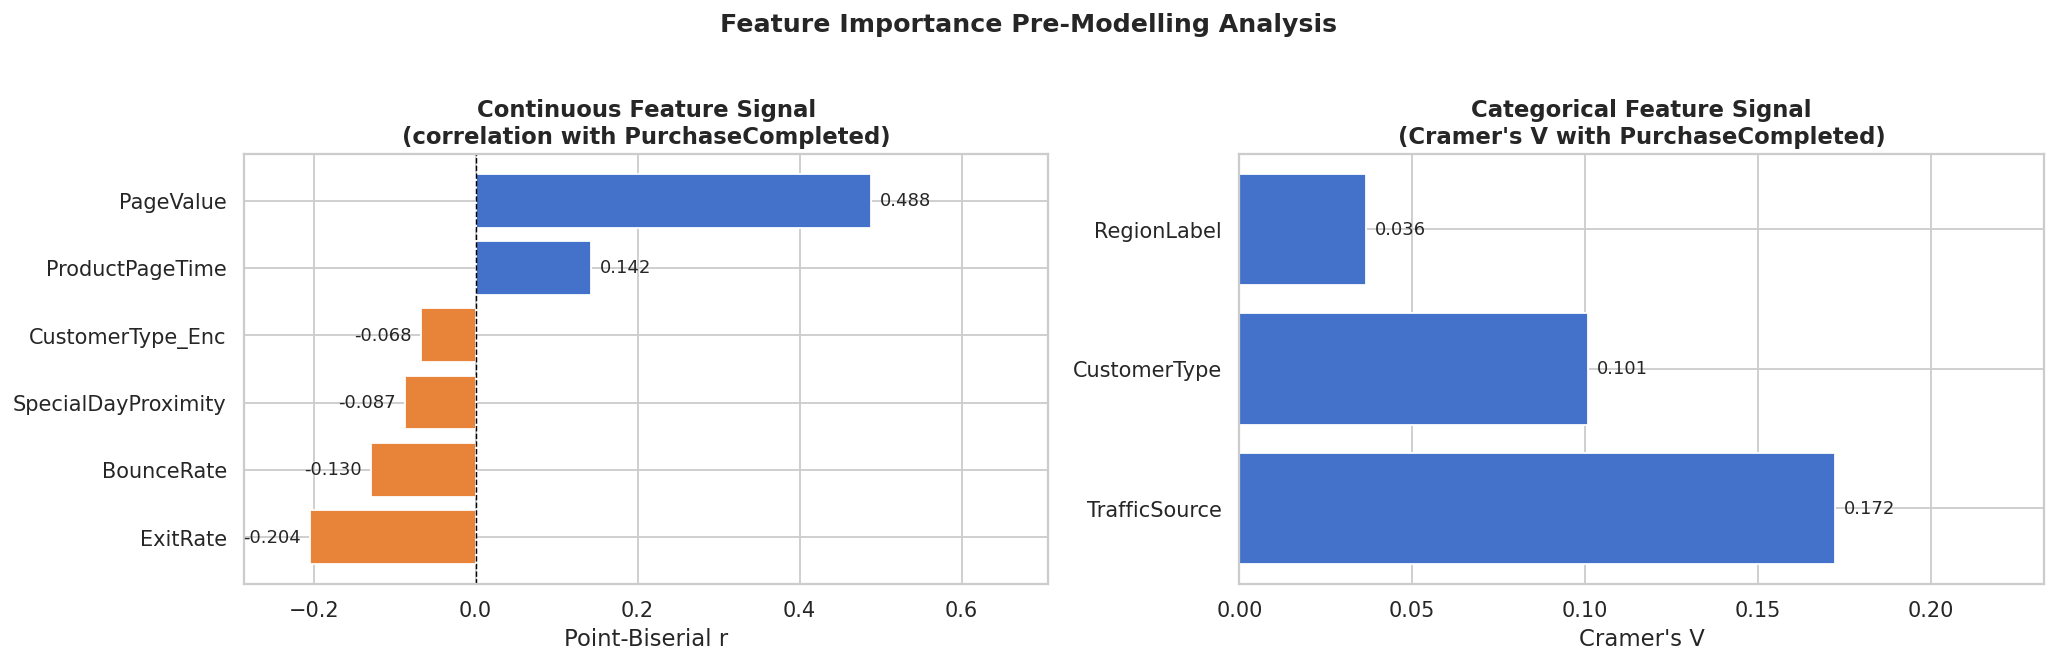


FEATURE RANKING:
  1. PageValue           r=+0.49  |  Dominant predictor
  2. ExitRate            r=-0.21  |  Strong negative signal
  3. BounceRate          r=-0.13  |  Collinear with ExitRate (r=0.81) -- use one only
  4. CustomerType        V=~0.09  |  New > Returning conversion
  5. TrafficSource       V=~0.07  |  Channel matters
  6. ProductPageTime     r=+0.06  |  Weak positive
  7. SpecialDayProximity r=-0.05  |  Weak negative (counter-intuitive)


In [30]:
# ── Feature importance chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_sorted = feat_df.sort_values("Pearson r")
clrs_c = [ACCENT_BLUE if v>=0 else ACCENT_AMBER for v in feat_sorted["Pearson r"]]
hbars = axes[0].barh(feat_sorted.index, feat_sorted["Pearson r"], color=clrs_c, edgecolor="white")
axes[0].axvline(0, color="black", lw=0.8, ls="--")
axes[0].bar_label(hbars, fmt="%.3f", padding=5, fontsize=10)
axes[0].set_xlabel("Point-Biserial r")
axes[0].set_title("Continuous Feature Signal\n(correlation with PurchaseCompleted)")
axes[0].set_xlim(feat_sorted["Pearson r"].min()*1.4, feat_sorted["Pearson r"].max()*1.45)

hbars2 = axes[1].barh(cramers_df.index, cramers_df["Cramer V"], color=ACCENT_BLUE, edgecolor="white")
axes[1].bar_label(hbars2, fmt="%.3f", padding=5, fontsize=10)
axes[1].set_xlabel("Cramer's V")
axes[1].set_title("Categorical Feature Signal\n(Cramer's V with PurchaseCompleted)")
axes[1].set_xlim(0, cramers_df["Cramer V"].max()*1.35)

plt.suptitle("Feature Importance Pre-Modelling Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print()
print("FEATURE RANKING:")
print("  1. PageValue           r=+0.49  |  Dominant predictor")
print("  2. ExitRate            r=-0.21  |  Strong negative signal")
print("  3. BounceRate          r=-0.13  |  Collinear with ExitRate (r=0.81) -- use one only")
print("  4. CustomerType        V=~0.09  |  New > Returning conversion")
print("  5. TrafficSource       V=~0.07  |  Channel matters")
print("  6. ProductPageTime     r=+0.06  |  Weak positive")
print("  7. SpecialDayProximity r=-0.05  |  Weak negative (counter-intuitive)")

---
# Section 8. Outlier Detection

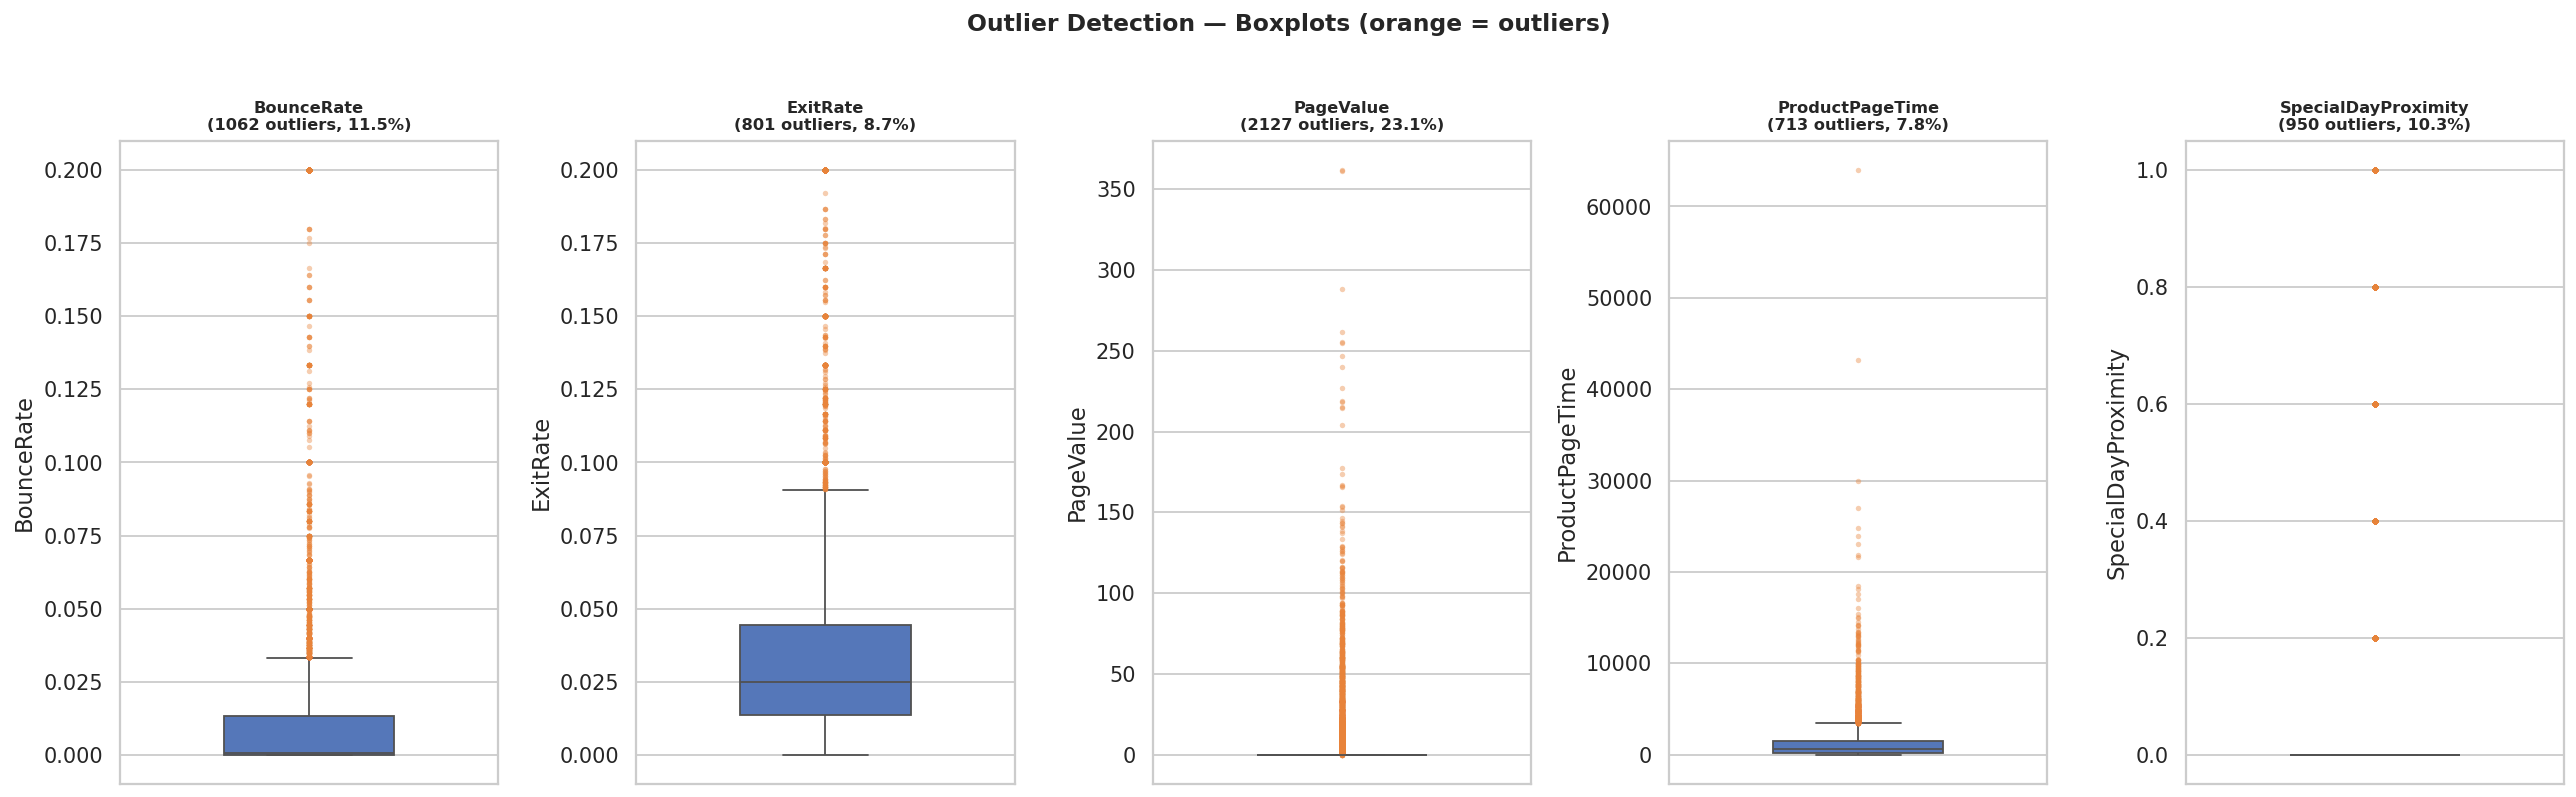

In [31]:
# ── Boxplot panel ─────────────────────────────────────────────────────────────
cont_5 = ["BounceRate","ExitRate","PageValue","ProductPageTime","SpecialDayProximity"]
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for ax, col in zip(axes, cont_5):
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3-q1
    n_out  = ((df[col]<q1-1.5*iqr)|(df[col]>q3+1.5*iqr)).sum()
    sns.boxplot(y=df[col], ax=ax, color=ACCENT_BLUE, width=0.45,
                flierprops=dict(marker="o",markerfacecolor=ACCENT_AMBER,markersize=3,alpha=0.4,markeredgewidth=0))
    ax.set_title(f"{col}\n({n_out} outliers, {n_out/len(df)*100:.1f}%)", fontsize=9, pad=6)
    ax.set_xlabel("")
plt.suptitle("Outlier Detection — Boxplots (orange = outliers)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

In [32]:
# ── IQR table ─────────────────────────────────────────────────────────────────
iqr_rows = []
for col in cont_5:
    q1, q3 = df[col].quantile([0.25, 0.75]); iqr = q3-q1; lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n_low, n_high = (df[col]<lo).sum(), (df[col]>hi).sum(); n_tot = n_low+n_high
    iqr_rows.append({"Feature":col,"Q1":round(q1,4),"Q3":round(q3,4),"IQR":round(iqr,4),
                     "Lower Fence":round(lo,4),"Upper Fence":round(hi,4),
                     "Low Out":n_low,"High Out":n_high,"Total Out":n_tot,"Outlier %":round(n_tot/len(df)*100,2)})
iqr_df = pd.DataFrame(iqr_rows).set_index("Feature")
print("IQR Outlier Summary:")
print(iqr_df.to_string())

IQR Outlier Summary:
                           Q1         Q3        IQR  Lower Fence  Upper Fence  Low Out  High Out  Total Out  Outlier %
Feature                                                                                                               
BounceRate             0.0000     0.0133     0.0133      -0.0200       0.0333        0      1062       1062      11.54
ExitRate               0.0135     0.0444     0.0310      -0.0329       0.0909        0       801        801       8.71
PageValue              0.0000     0.0000     0.0000       0.0000       0.0000        0      2127       2127      23.12
ProductPageTime      219.5375  1523.4746  1303.9371   -1736.3681    3479.3802        0       713        713       7.75
SpecialDayProximity    0.0000     0.0000     0.0000       0.0000       0.0000        0       950        950      10.33


In [33]:
# ── Z-score ───────────────────────────────────────────────────────────────────
print("Z-score outliers (|z| > 3):")
for col in cont_5:
    z = np.abs(stats.zscore(df[col].dropna())); n_ext = (z>3).sum()
    print(f"  {col:25s}: {n_ext:4d}  ({n_ext/len(df)*100:.2f}%)")

print()
print("OUTLIER IMPLICATIONS:")
print("  ProductPageTime: max 63,973 s (~17.8 hrs) — idle tabs. Recommend cap at 3,600 s.")
print("  PageValue: max $361.76 — genuine high-value product visits. DO NOT drop; use log1p.")
print("  BounceRate/ExitRate: bounded [0,1]; extreme values are real behaviour.")

Z-score outliers (|z| > 3):
  BounceRate               :  245  (2.66%)
  ExitRate                 :  257  (2.79%)
  PageValue                :  186  (2.02%)
  ProductPageTime          :  156  (1.70%)
  SpecialDayProximity      :  363  (3.95%)

OUTLIER IMPLICATIONS:
  ProductPageTime: max 63,973 s (~17.8 hrs) — idle tabs. Recommend cap at 3,600 s.
  PageValue: max $361.76 — genuine high-value product visits. DO NOT drop; use log1p.
  BounceRate/ExitRate: bounded [0,1]; extreme values are real behaviour.


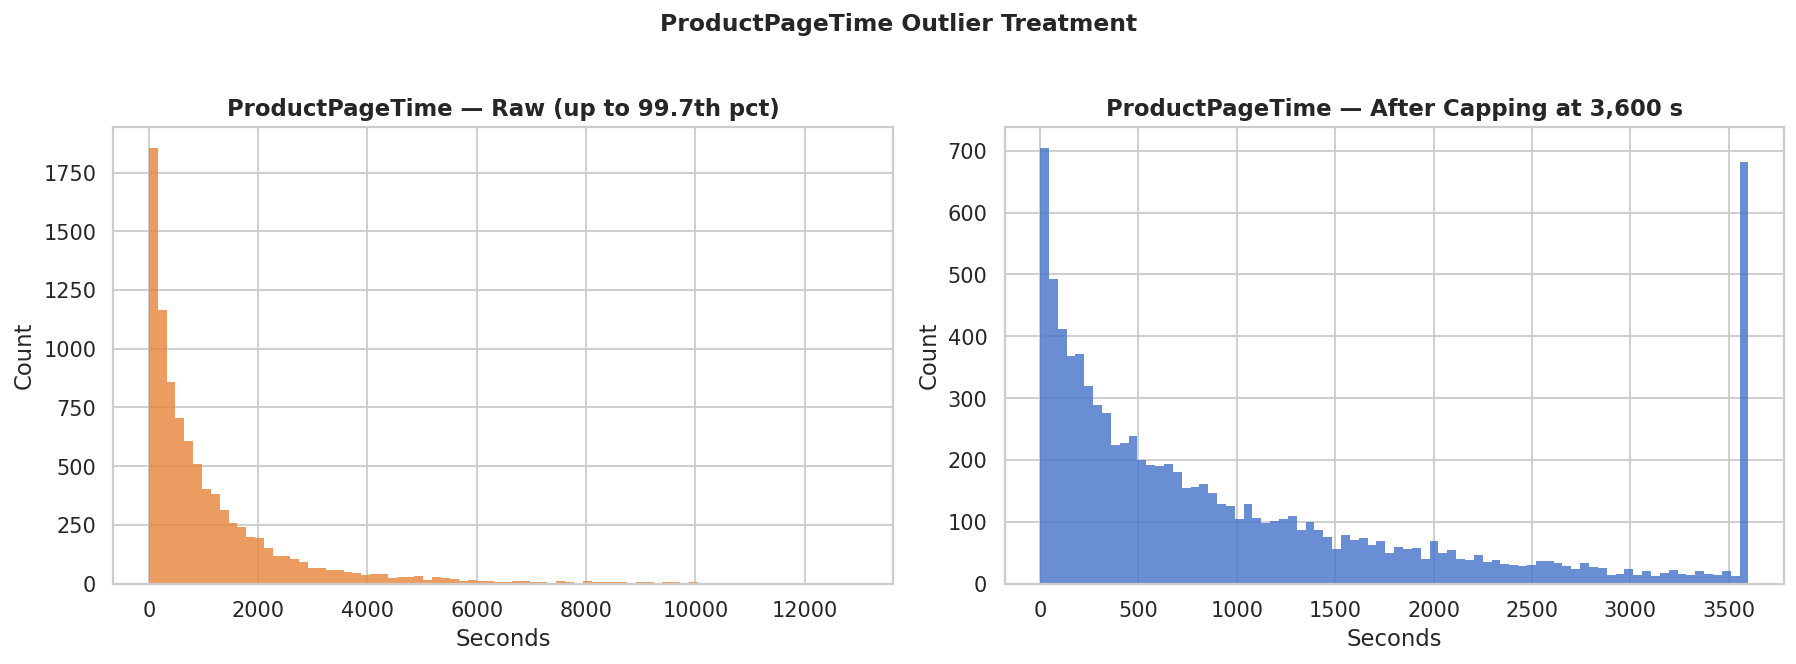

In [34]:
# ── ProductPageTime outlier treatment ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
raw = df["ProductPageTime"]; capped = raw.clip(upper=3600)

axes[0].hist(raw[raw<=raw.quantile(0.997)], bins=80, color=ACCENT_AMBER, edgecolor="none", alpha=0.8)
axes[0].set_title("ProductPageTime — Raw (up to 99.7th pct)")
axes[0].set_xlabel("Seconds"); axes[0].set_ylabel("Count")

axes[1].hist(capped, bins=80, color=ACCENT_BLUE, edgecolor="none", alpha=0.8)
axes[1].set_title("ProductPageTime — After Capping at 3,600 s")
axes[1].set_xlabel("Seconds"); axes[1].set_ylabel("Count")

plt.suptitle("ProductPageTime Outlier Treatment", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

---
# Section 9. Key Findings & Business Insights

### Most Important Patterns

| Rank | Finding |
|------|---------|
| 1 | **PageValue is the dominant predictor** (r=+0.49) |
| 2 | **15.5% overall conversion rate** |
| 3 | **New Visitors convert ~25% vs Returning ~14%** |
| 4 | **High exit/bounce sessions almost never convert** |
| 5 | **Traffic Source dramatically affects conversion** |
| 6 | **Special day proximity LOWERS conversion** |
| 7 | **5% block-missing data** |

### Data Quality Issues

| Issue | Severity | Action |
|-------|----------|--------|
| 616 rows with block-missing values | Medium | Fix upstream data collection pipeline |
| 7 dirty `CustomerType` labels | Low | Normalised in preprocessing |
| Negative `BounceRate` values (n=348) | Low | Clipped; investigate sensor causing negatives |
| `ProductPageTime` > 3,600 s | Low | Implement session timeout in analytics |

In [37]:
import shutil
import os

# Define source and destination paths
DB_SOURCE_PATH = "/content/online_shopping.db"
DRIVE_DEST_DIR = "/content/drive/MyDrive/Colab Notebooks/"
DRIVE_DEST_PATH = os.path.join(DRIVE_DEST_DIR, "online_shopping.db")

# Create the destination directory if it doesn't exist
os.makedirs(DRIVE_DEST_DIR, exist_ok=True)

# Copy the file to Google Drive
shutil.copy(DB_SOURCE_PATH, DRIVE_DEST_PATH)

print(f"File '{DB_SOURCE_PATH}' copied to '{DRIVE_DEST_PATH}' successfully.")

File '/content/online_shopping.db' copied to '/content/drive/MyDrive/Colab Notebooks/online_shopping.db' successfully.


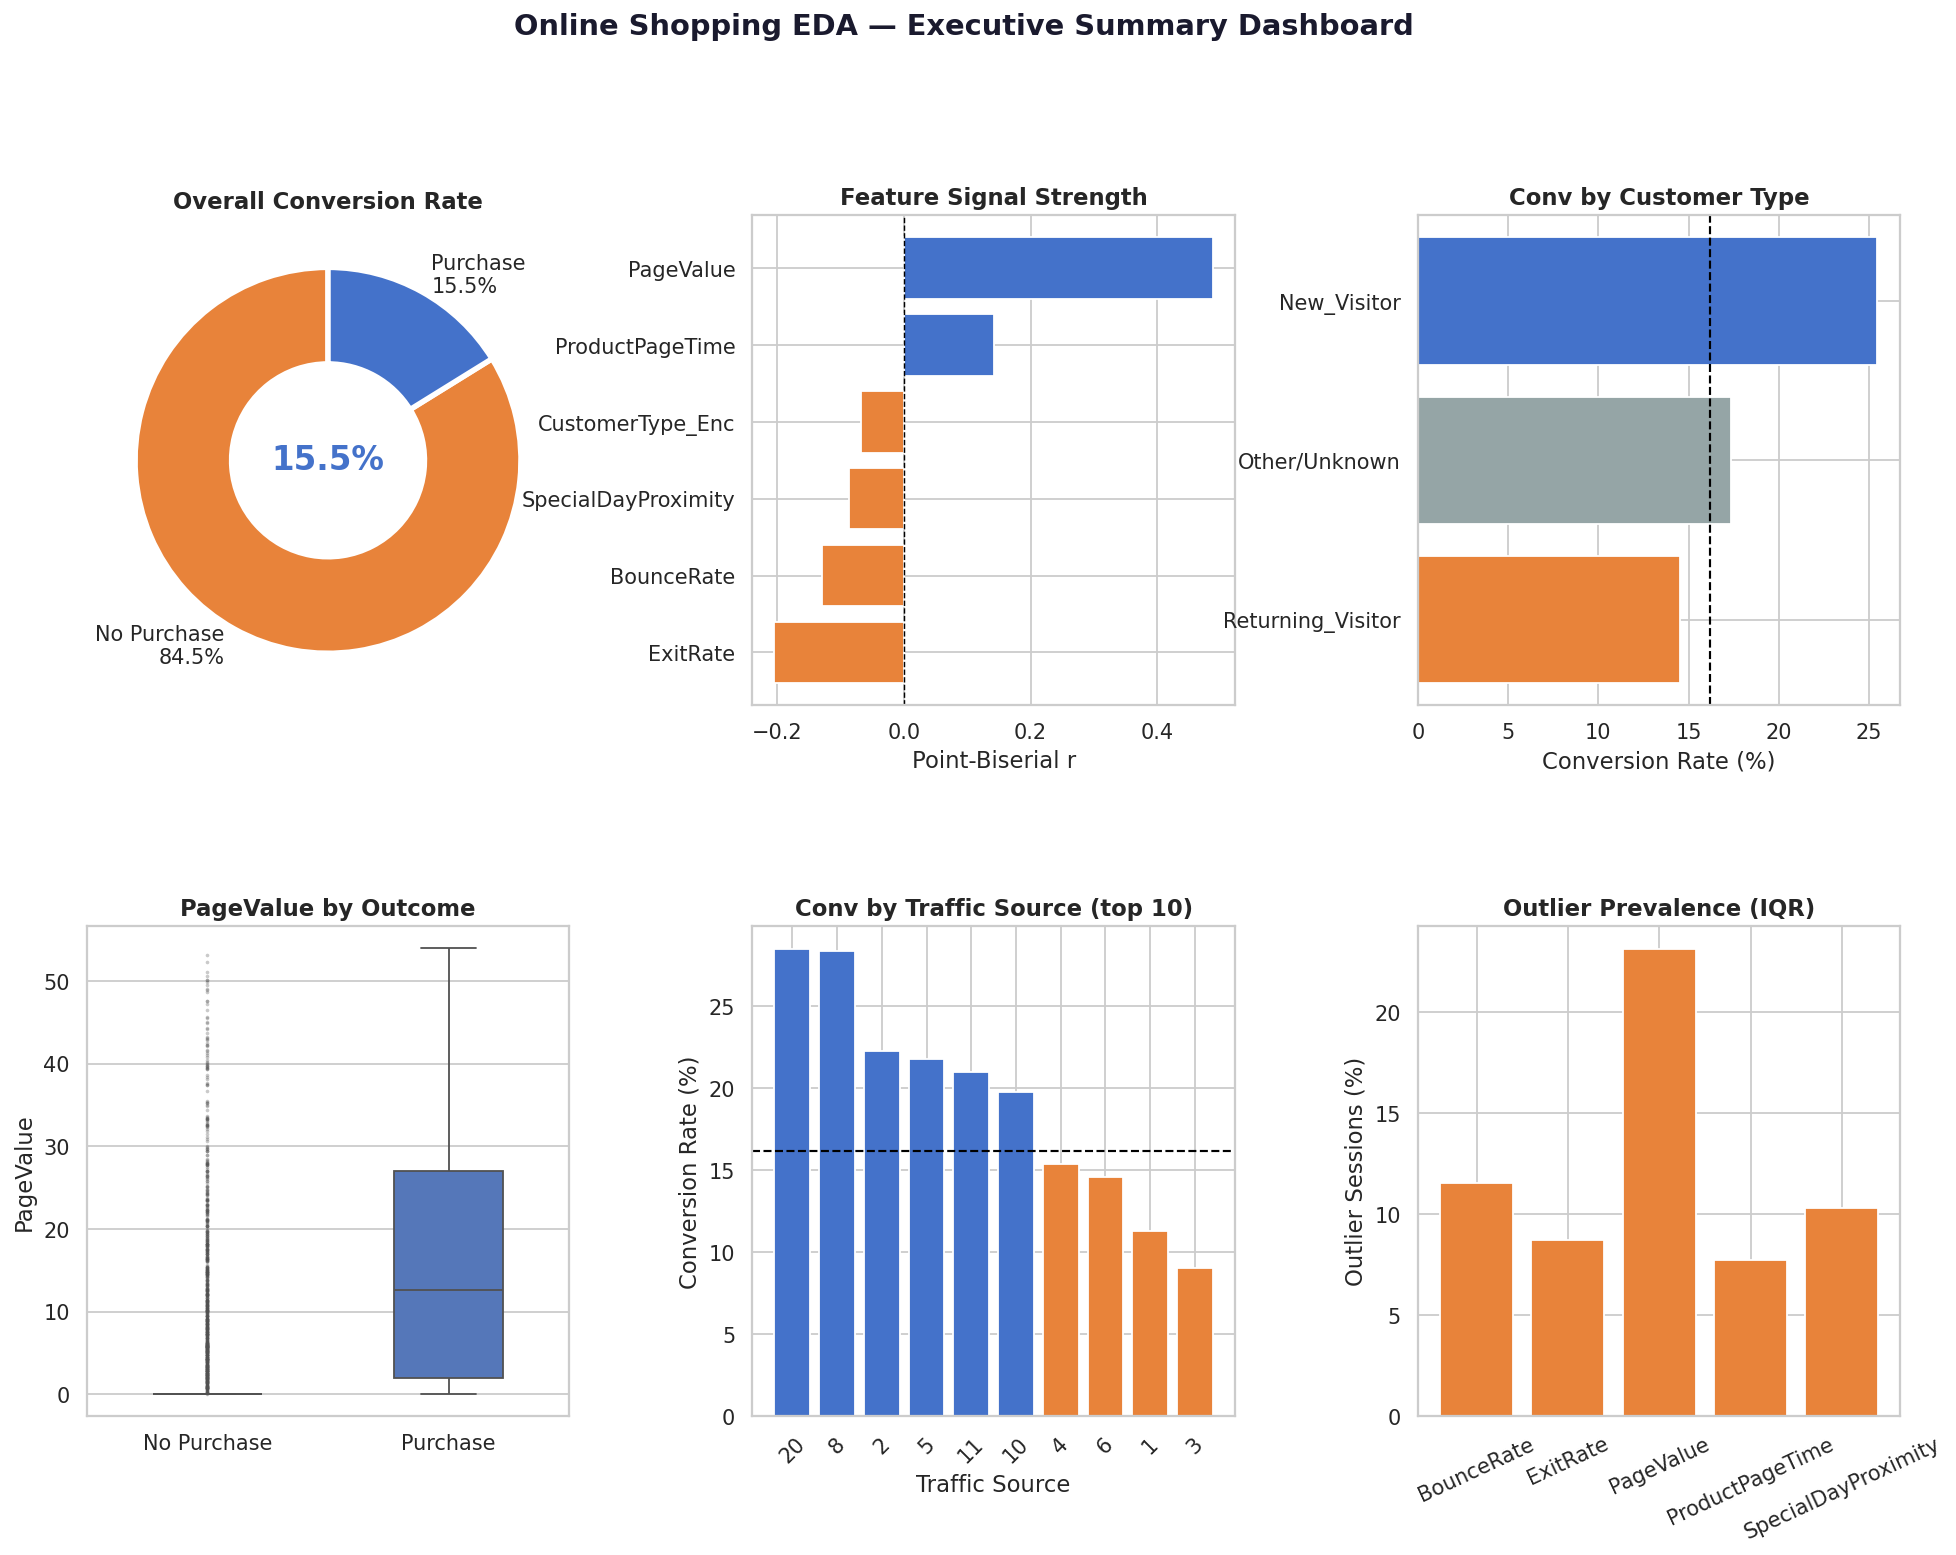

In [35]:
# ── Executive dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor("white")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# P1: Donut
ax1 = fig.add_subplot(gs[0,0])
vc  = df["PurchaseCompleted"].value_counts().sort_index()
ax1.pie(vc.values, labels=["No Purchase\n84.5%","Purchase\n15.5%"], autopct="",
        colors=[ACCENT_AMBER,ACCENT_BLUE], wedgeprops=dict(width=0.5,edgecolor="white",linewidth=3), startangle=90)
ax1.set_title("Overall Conversion Rate", fontweight="bold")
ax1.text(0,0,"15.5%",ha="center",va="center",fontsize=18,fontweight="bold",color=ACCENT_BLUE)

# P2: Feature importance
ax2 = fig.add_subplot(gs[0,1])
fi  = feat_df["Pearson r"].sort_values()
ax2.barh(fi.index, fi.values, color=[ACCENT_BLUE if v>=0 else ACCENT_AMBER for v in fi.values], edgecolor="white")
ax2.axvline(0, color="black", lw=0.8, ls="--"); ax2.set_xlabel("Point-Biserial r")
ax2.set_title("Feature Signal Strength", fontweight="bold")

# P3: Conv by customer type
ax3 = fig.add_subplot(gs[0,2])
ct_c = df.groupby("CustomerType")["PurchaseCompleted"].mean().sort_values(ascending=True)*100
ax3.barh(ct_c.index, ct_c.values, color=[ACCENT_AMBER,NEUTRAL_GREY,ACCENT_BLUE], edgecolor="white")
ax3.axvline(avg_rate, color="black", ls="--", lw=1.2)
ax3.set_xlabel("Conversion Rate (%)"); ax3.set_title("Conv by Customer Type", fontweight="bold")

# P4: PageValue boxplot
ax4 = fig.add_subplot(gs[1,0])
df_pv4 = df[df["PageValue"]<=df["PageValue"].quantile(0.97)].copy()
df_pv4["Outcome"] = df_pv4["PurchaseCompleted"].map({0:"No Purchase",1:"Purchase"})
sns.boxplot(data=df_pv4, x="Outcome", y="PageValue",
            palette={"No Purchase":ACCENT_AMBER,"Purchase":ACCENT_BLUE},
            width=0.45, flierprops=dict(marker=".",ms=2,alpha=0.3), ax=ax4)
ax4.set_title("PageValue by Outcome", fontweight="bold"); ax4.set_xlabel("")

# P5: Conv by traffic source
ax5 = fig.add_subplot(gs[1,1])
top_conv = conv_ts.head(10)
ax5.bar(top_conv["TrafficSource"].astype(str), top_conv["conv_rate"],
        color=[ACCENT_BLUE if r>avg_rate else ACCENT_AMBER for r in top_conv["conv_rate"]], edgecolor="white")
ax5.axhline(avg_rate, color="black", ls="--", lw=1.2)
ax5.set_xlabel("Traffic Source"); ax5.set_ylabel("Conversion Rate (%)")
ax5.set_title("Conv by Traffic Source (top 10)", fontweight="bold"); ax5.tick_params(axis="x", rotation=45)

# P6: Outlier %
ax6 = fig.add_subplot(gs[1,2])
ax6.bar(iqr_df.index, iqr_df["Outlier %"],
        color=[ACCENT_AMBER if v>5 else ACCENT_BLUE for v in iqr_df["Outlier %"]], edgecolor="white")
ax6.set_ylabel("Outlier Sessions (%)"); ax6.tick_params(axis="x", rotation=25)
ax6.set_title("Outlier Prevalence (IQR)", fontweight="bold")

fig.suptitle("Online Shopping EDA — Executive Summary Dashboard",
             fontsize=16, fontweight="bold", y=1.01, color=BRAND_DARK)
plt.show()